In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Load the dataset
df = pd.read_csv('final_cleaned_housing_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (269746, 31)

First few rows:


,status,street,schools,zipcode,state,target,private_pool,property_category,baths,beds,...,parking_spaces,has_garage,year_built,year_remodeled,lot_size,missing_year_built,was_remodeled,property_age,years_since_remodel,years_to_remodel
0,for sale,240 Heather Ln,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",28387,NC,418000.0,No,single_family,3.5,4.0,...,0,False,2019.0,2019.0,8700.0,0,0,6.0,6.0,0.0
1,for sale,12911 E Heroy Ave,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",99216,WA,310000.0,No,single_family,3.0,3.0,...,0,False,2019.0,2019.0,5828.0,0,0,6.0,6.0,0.0
2,for sale,2005 Westridge Rd,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...",90049,CA,2895000.0,Yes,single_family,2.0,3.0,...,1,True,1961.0,1967.0,8626.0,0,1,64.0,58.0,6.0
3,for sale,4311 Livingston Ave,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...",75205,TX,2395000.0,No,single_family,8.0,5.0,...,1,True,2006.0,2006.0,8220.0,0,1,19.0,19.0,0.0
4,for sale,1624 S Newkirk St,"[{'rating': [], 'data': {'Distance': [], 'Grad...",19145,PA,209000.0,No,townhouse,2.5,2.0,...,0,False,1920.0,1920.0,1794.0,0,0,105.0,105.0,0.0


# Housing Price Prediction - Exploratory Data Analysis

## Overview
This notebook performs comprehensive exploratory data analysis on the housing dataset to understand price patterns, feature relationships, and data characteristics for machine learning model development.

## Dataset Summary
- **Records**: 269,746 properties
- **Features**: 31 original features
- **Target**: House prices (continuous variable)
- **Scope**: Multi-state housing market data

---

## 1. Initial Data Exploration

## 2. Target Variable Analysis

**Objective**: Understand the distribution and characteristics of house prices to inform modeling approach.

**Key Questions**:
- What is the price distribution shape?
- Are there extreme outliers?
- Does the data suggest log-normal distribution?

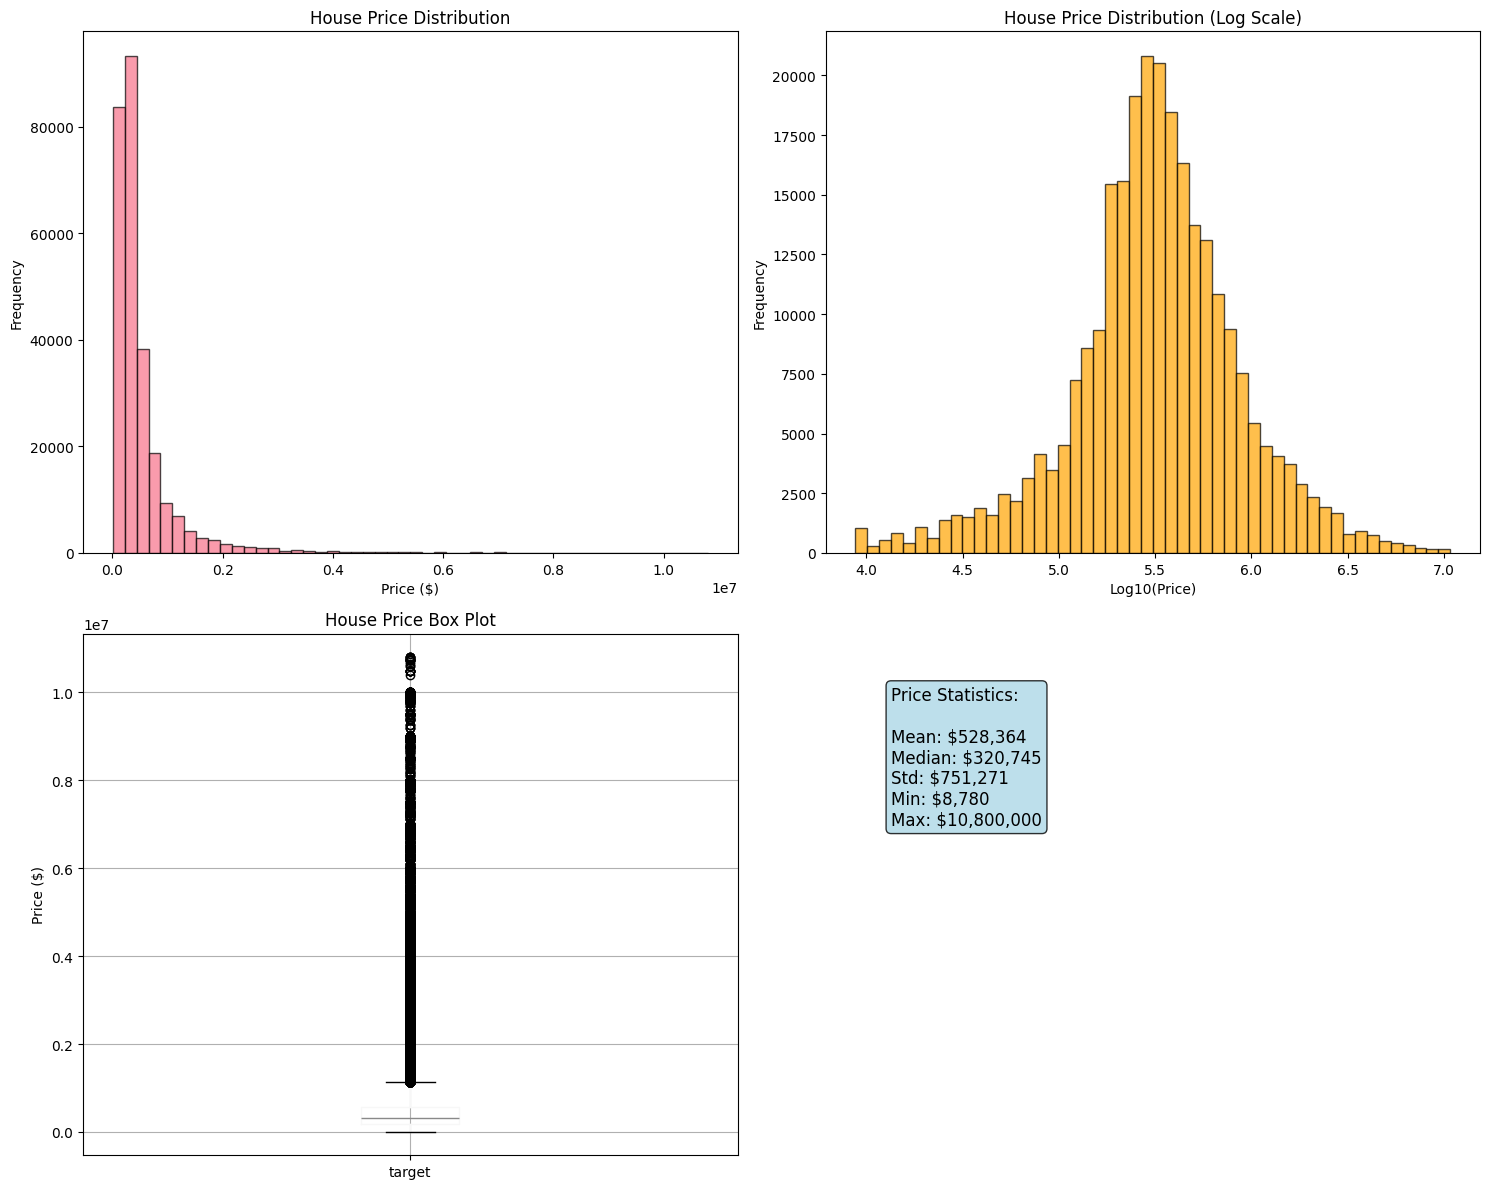

Price range: $8,780 - $10,800,000
Number of properties above $1M: 27,931
Percentage above $1M: 10.4%


In [149]:
# 1. Target Price Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0,0].hist(df['target'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('House Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')

# Log scale histogram
axes[0,1].hist(np.log10(df['target']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_title('House Price Distribution (Log Scale)')
axes[0,1].set_xlabel('Log10(Price)')
axes[0,1].set_ylabel('Frequency')

# Box plot
df.boxplot(column='target', ax=axes[1,0])
axes[1,0].set_title('House Price Box Plot')
axes[1,0].set_ylabel('Price ($)')

# Summary statistics
price_stats = df['target'].describe()
axes[1,1].text(0.1, 0.9, f"Price Statistics:\n\n"
                         f"Mean: ${price_stats['mean']:,.0f}\n"
                         f"Median: ${price_stats['50%']:,.0f}\n"
                         f"Std: ${price_stats['std']:,.0f}\n"
                         f"Min: ${price_stats['min']:,.0f}\n"
                         f"Max: ${price_stats['max']:,.0f}",
               transform=axes[1,1].transAxes, fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print(f"Price range: ${df['target'].min():,.0f} - ${df['target'].max():,.0f}")
print(f"Number of properties above $1M: {(df['target'] > 1000000).sum():,}")
print(f"Percentage above $1M: {(df['target'] > 1000000).mean()*100:.1f}%")

### Key Findings - Price Distribution
- **Distribution**: Right-skewed with log-normal characteristics
- **Price Range**: Wide variance suggesting diverse market segments
- **Outliers**: Extreme high-end properties identified
- **Modeling Impact**: Log transformation likely beneficial for linear models

---

## 3. Geographic Analysis

**Objective**: Analyze price variations across states and identify geographic patterns.

**Key Questions**:
- Which states have highest/lowest average prices?
- What is the geographic distribution of properties?
- Are there regional price patterns?

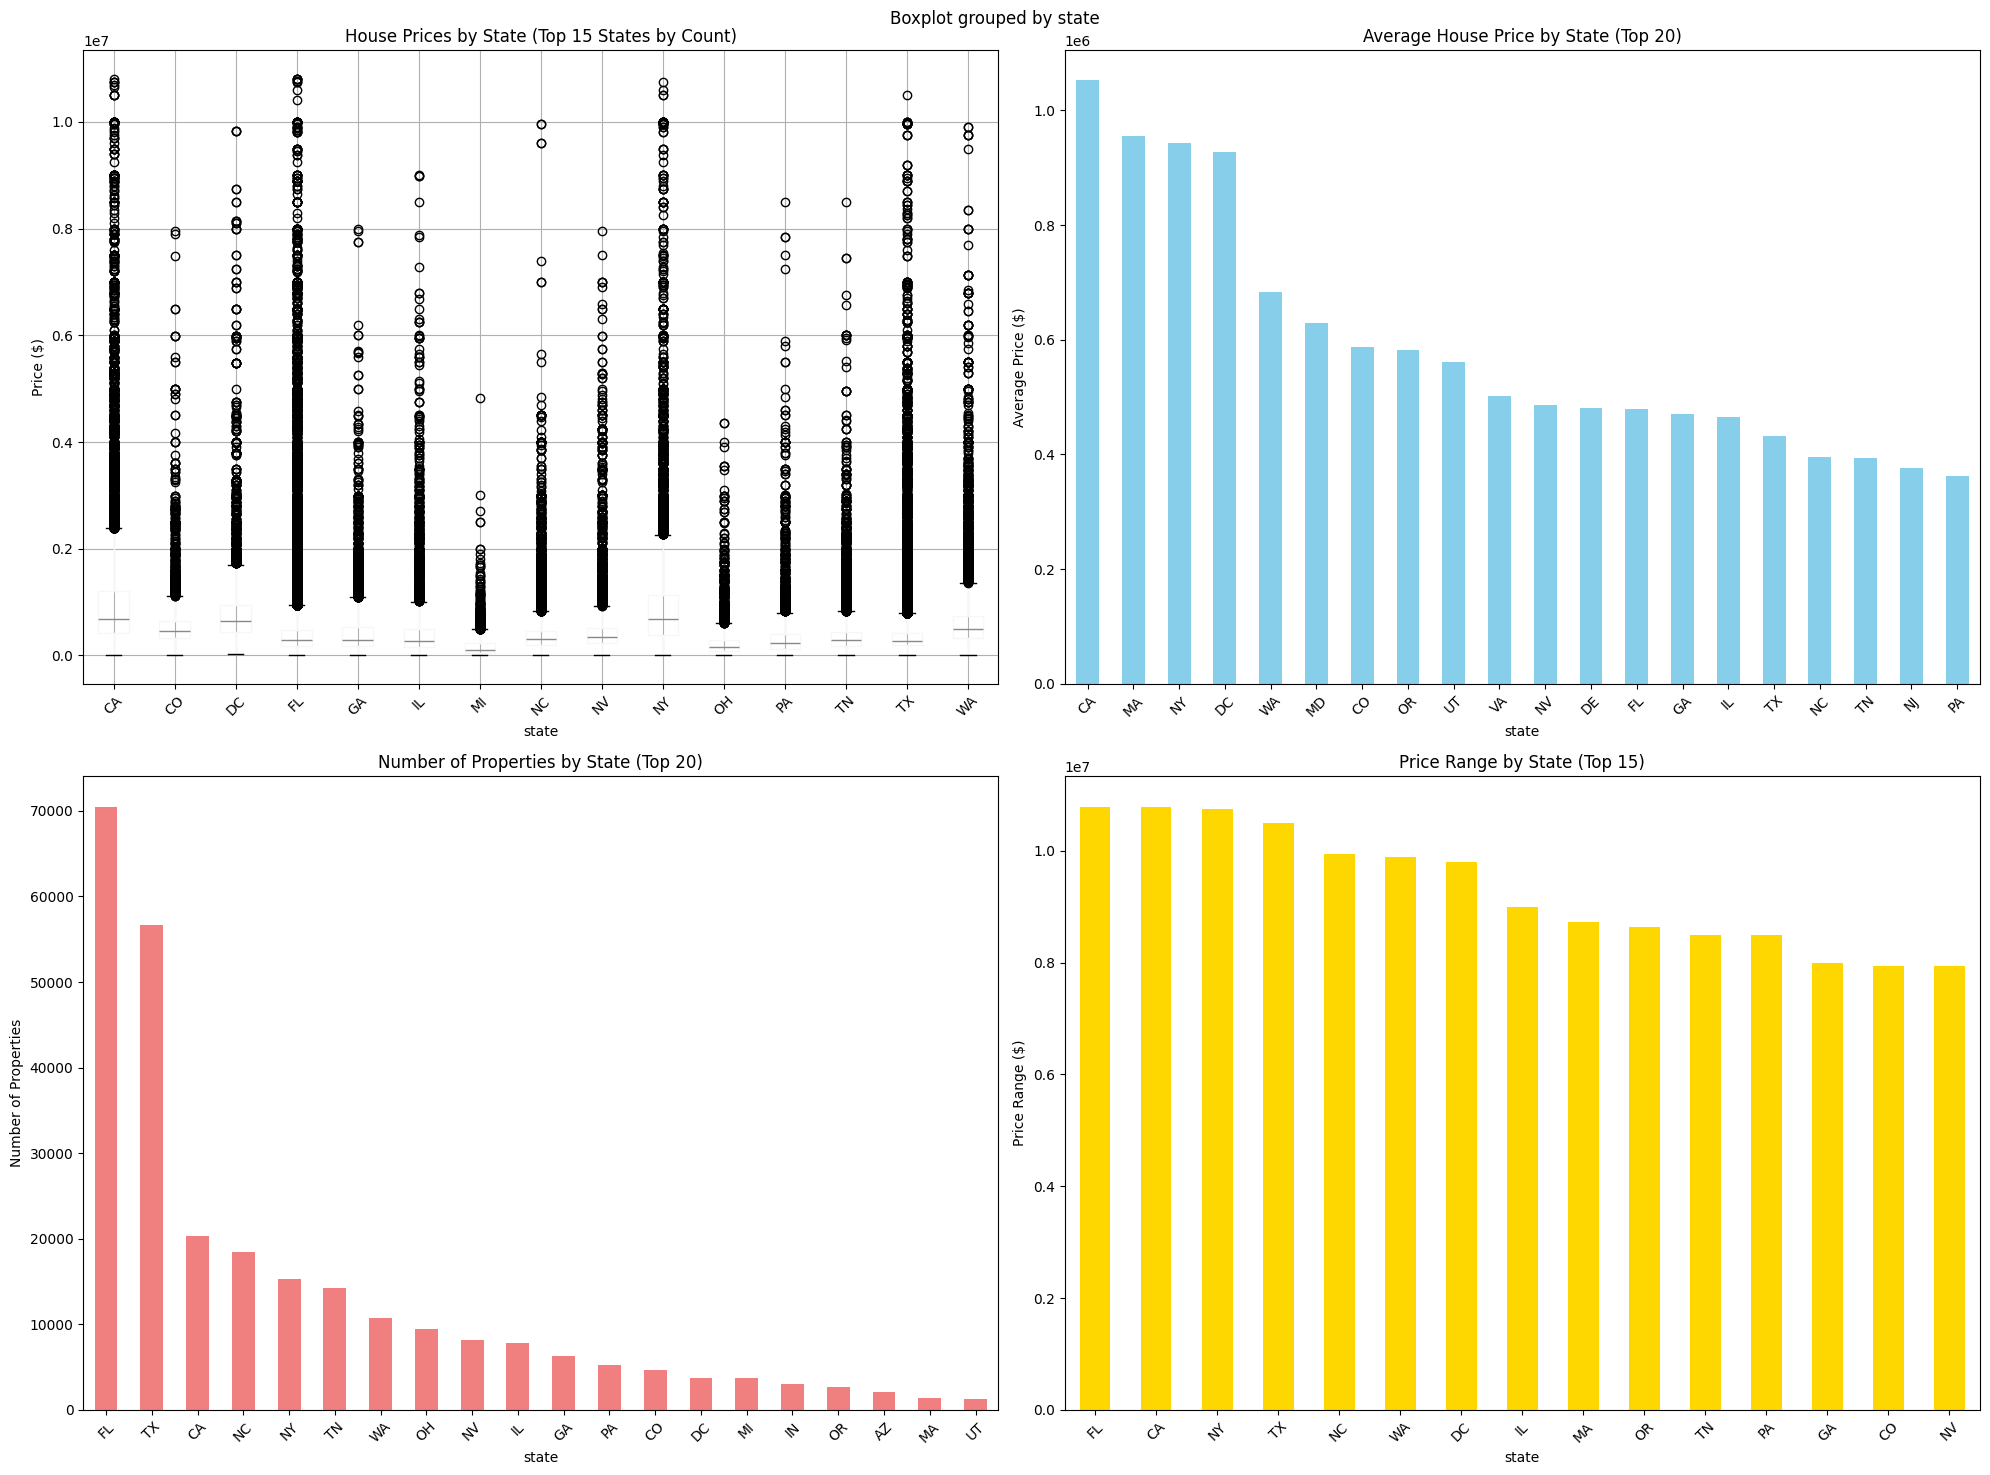

State Statistics:
Number of states: 34
Most expensive state (avg): CA - $1,052,231
Most properties: FL - 70,501 properties


In [150]:
# 2. Price by State Analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Box plot by state (top states)
state_counts = df['state'].value_counts()
top_states = state_counts.head(15).index

plt.subplot(2, 2, 1)
df[df['state'].isin(top_states)].boxplot(column='target', by='state', ax=plt.gca())
plt.title('House Prices by State (Top 15 States by Count)')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')

# Average price by state
plt.subplot(2, 2, 2)
state_avg_price = df.groupby('state')['target'].mean().sort_values(ascending=False).head(20)
state_avg_price.plot(kind='bar', color='skyblue')
plt.title('Average House Price by State (Top 20)')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Property count by state
plt.subplot(2, 2, 3)
state_counts.head(20).plot(kind='bar', color='lightcoral')
plt.title('Number of Properties by State (Top 20)')
plt.xticks(rotation=45)
plt.ylabel('Number of Properties')

# Price range (max-min) by state
plt.subplot(2, 2, 4)
state_price_range = df.groupby('state')['target'].agg(['min', 'max'])
state_price_range['range'] = state_price_range['max'] - state_price_range['min']
state_price_range.sort_values('range', ascending=False).head(15)['range'].plot(kind='bar', color='gold')
plt.title('Price Range by State (Top 15)')
plt.xticks(rotation=45)
plt.ylabel('Price Range ($)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("State Statistics:")
print(f"Number of states: {df['state'].nunique()}")
print(f"Most expensive state (avg): {state_avg_price.index[0]} - ${state_avg_price.iloc[0]:,.0f}")
print(f"Most properties: {state_counts.index[0]} - {state_counts.iloc[0]:,} properties")

### Key Findings - Geographic Analysis
- **State Variations**: Significant price differences across states
- **Market Concentration**: Properties concentrated in specific regions
- **Price Ranges**: Each state shows distinct pricing patterns
- **Modeling Impact**: State is a strong predictor variable

---

## 4. Property Characteristics Analysis

**Objective**: Understand how property types and physical characteristics affect pricing.

**Key Questions**:
- How do different property categories compare in price?
- What are the most common property types?
- Are there category-specific pricing patterns?

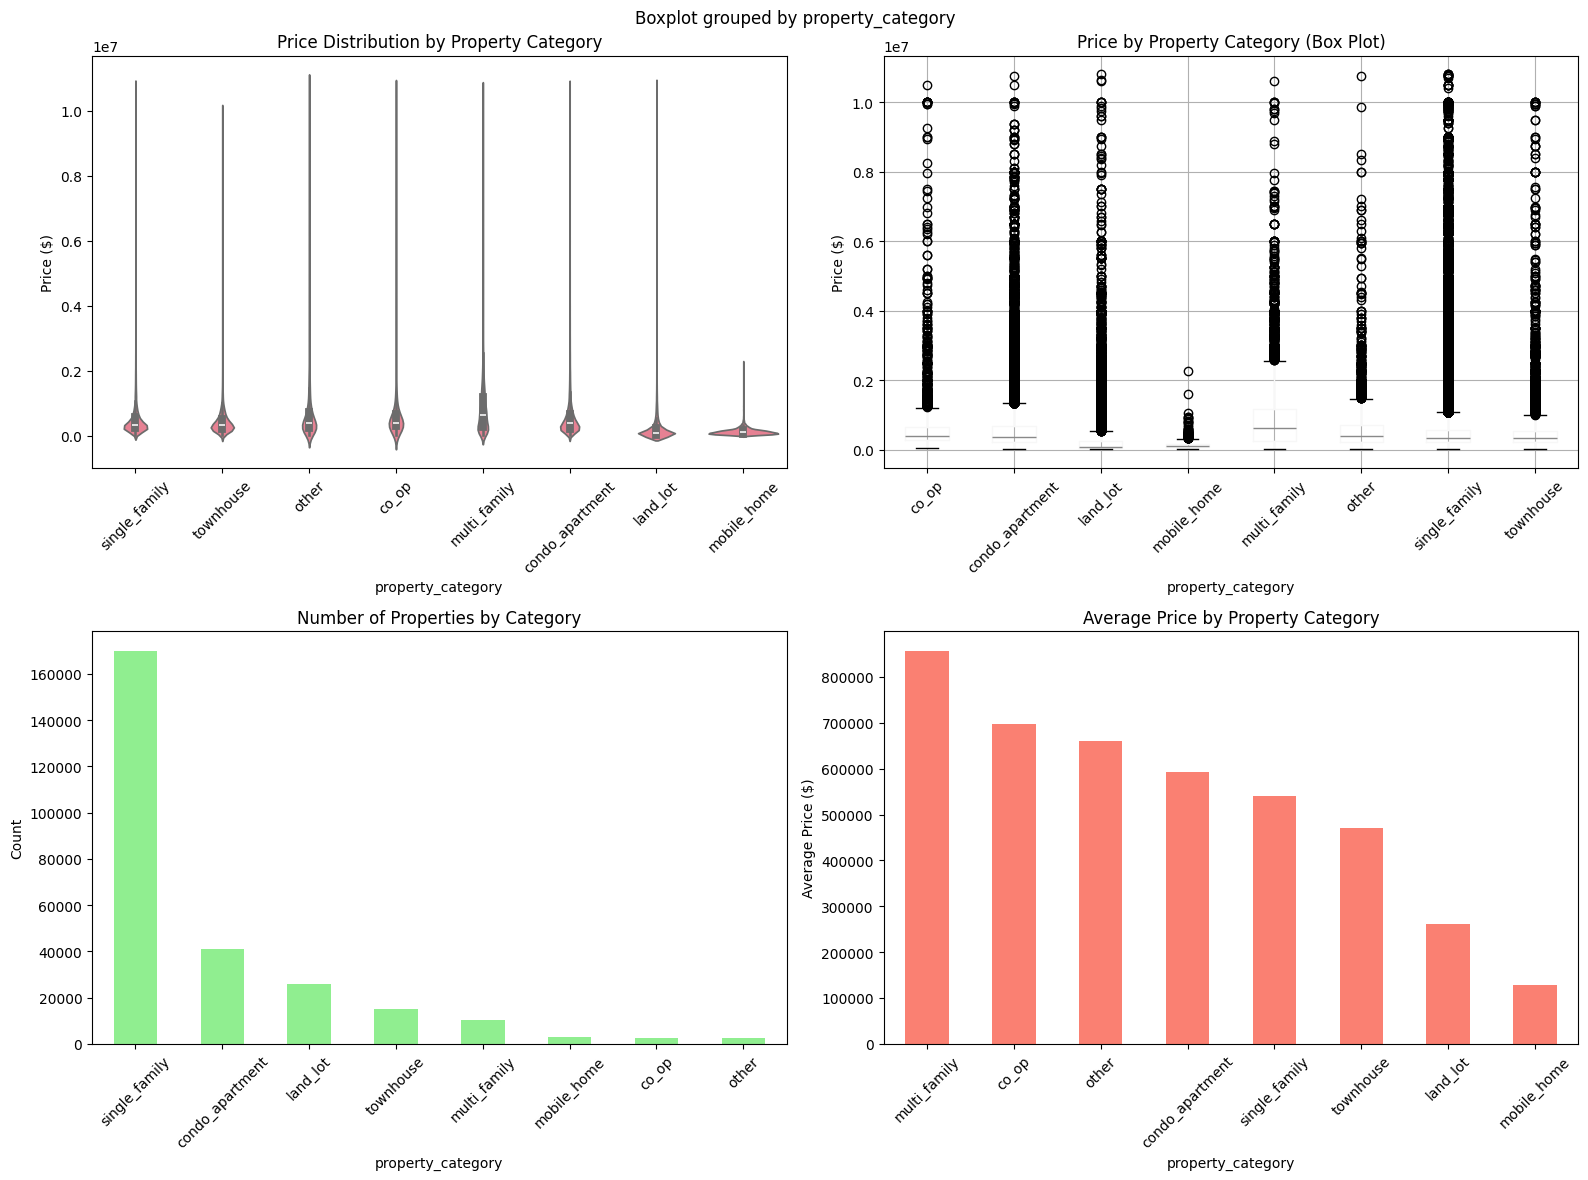

Property Category Analysis:

SINGLE_FAMILY:
  Count: 169,809
  Avg Price: $541,543
  Median Price: $334,990
  Price Range: $10,000 - $10,800,000

TOWNHOUSE:
  Count: 15,168
  Avg Price: $469,661
  Median Price: $323,995
  Price Range: $18,000 - $10,000,000

OTHER:
  Count: 2,538
  Avg Price: $660,798
  Median Price: $376,500
  Price Range: $17,900 - $10,750,000

CO_OP:
  Count: 2,547
  Avg Price: $698,290
  Median Price: $388,000
  Price Range: $32,000 - $10,500,000

MULTI_FAMILY:
  Count: 10,117
  Avg Price: $856,467
  Median Price: $624,999
  Price Range: $19,900 - $10,600,000

CONDO_APARTMENT:
  Count: 40,908
  Avg Price: $591,946
  Median Price: $372,453
  Price Range: $14,900 - $10,750,000

LAND_LOT:
  Count: 25,702
  Avg Price: $261,805
  Median Price: $79,900
  Price Range: $8,780 - $10,800,000

MOBILE_HOME:
  Count: 2,957
  Avg Price: $127,373
  Median Price: $104,500
  Price Range: $9,000 - $2,250,000


In [151]:
# 3. Price by Property Category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Violin plot
plt.subplot(2, 2, 1)
sns.violinplot(data=df, x='property_category', y='target')
plt.title('Price Distribution by Property Category')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')

# Box plot
plt.subplot(2, 2, 2)
df.boxplot(column='target', by='property_category', ax=plt.gca())
plt.title('Price by Property Category (Box Plot)')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')

# Count by category
plt.subplot(2, 2, 3)
category_counts = df['property_category'].value_counts()
category_counts.plot(kind='bar', color='lightgreen')
plt.title('Number of Properties by Category')
plt.xticks(rotation=45)
plt.ylabel('Count')

# Average price by category
plt.subplot(2, 2, 4)
category_avg_price = df.groupby('property_category')['target'].mean().sort_values(ascending=False)
category_avg_price.plot(kind='bar', color='salmon')
plt.title('Average Price by Property Category')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

# Summary statistics by category
print("Property Category Analysis:")
for category in df['property_category'].unique():
    subset = df[df['property_category'] == category]
    print(f"\n{category.upper()}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Avg Price: ${subset['target'].mean():,.0f}")
    print(f"  Median Price: ${subset['target'].median():,.0f}")
    print(f"  Price Range: ${subset['target'].min():,.0f} - ${subset['target'].max():,.0f}")

### Key Findings - Property Categories
- **Dominant Type**: Single-family homes are most common
- **Price Hierarchy**: Clear pricing patterns by property type
- **Market Segments**: Each category serves different market segments
- **Modeling Impact**: Property category is a key feature for prediction

---

## 5. Room Configuration Analysis

**Objective**: Analyze the relationship between bedrooms, bathrooms, and pricing.

**Key Questions**:
- What is the correlation between rooms and price?
- Which bed/bath combinations are most common?
- Are there optimal room ratios for value?

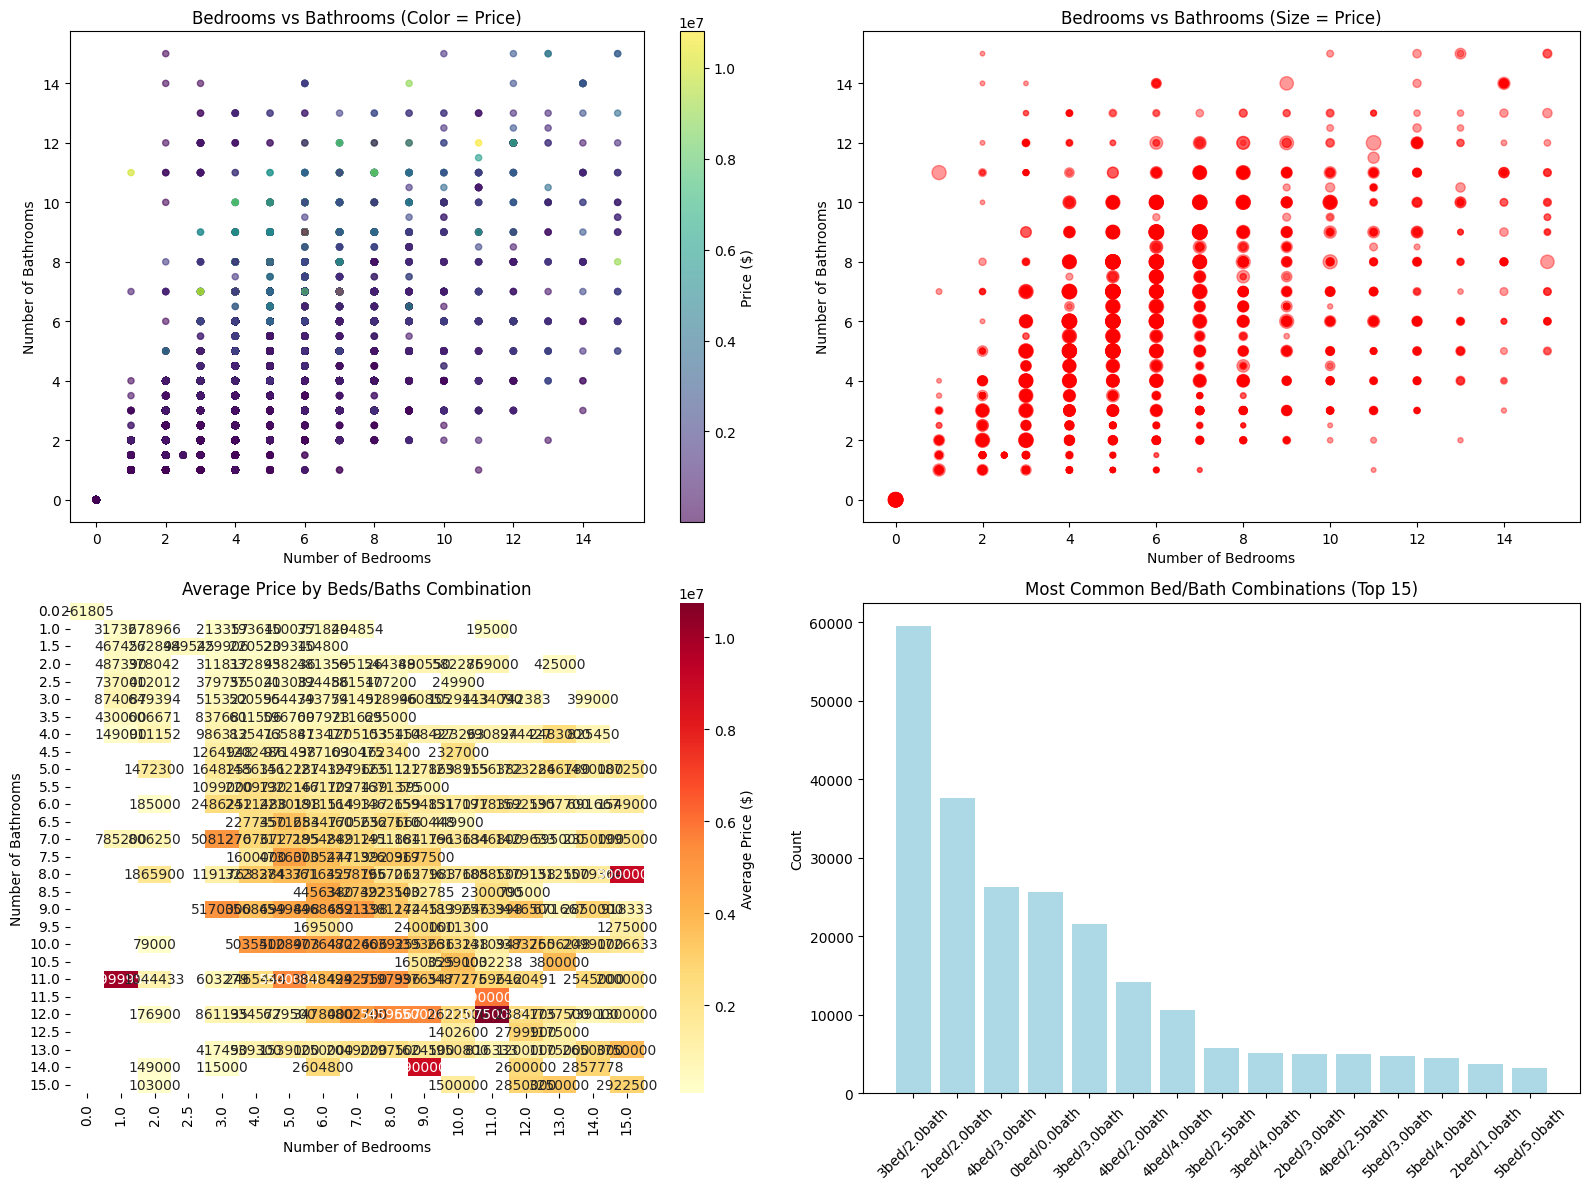

Beds vs Baths Analysis:
Bedroom range: 0 - 15
Bathroom range: 0.0 - 15.0
Most common combination: 3 bed / 2.0 bath
Highest avg price combination: 11 bed / 12.0 bath - $10,750,000


In [152]:
# 4. Beds vs Baths Scatter Plot with Price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot with price as color
plt.subplot(2, 2, 1)
scatter = plt.scatter(df['beds'], df['baths'], c=df['target'], alpha=0.6, cmap='viridis', s=20)
plt.colorbar(scatter, label='Price ($)')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Bathrooms')
plt.title('Bedrooms vs Bathrooms (Color = Price)')

# Scatter plot with size based on price
plt.subplot(2, 2, 2)
# Normalize price for size (avoid too large dots)
size = (df['target'] - df['target'].min()) / (df['target'].max() - df['target'].min()) * 100 + 10
plt.scatter(df['beds'], df['baths'], s=size, alpha=0.4, c='red')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Bathrooms')
plt.title('Bedrooms vs Bathrooms (Size = Price)')

# Average price by bed/bath combination
plt.subplot(2, 2, 3)
bed_bath_price = df.groupby(['beds', 'baths'])['target'].mean().reset_index()
# Create pivot table for heatmap
pivot_table = bed_bath_price.pivot(index='baths', columns='beds', values='target')
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Average Price ($)'})
plt.title('Average Price by Beds/Baths Combination')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Bathrooms')

# Distribution of bed/bath combinations
plt.subplot(2, 2, 4)
bed_bath_count = df.groupby(['beds', 'baths']).size().reset_index(name='count')
top_combinations = bed_bath_count.nlargest(15, 'count')
combination_labels = [f"{int(row['beds'])}bed/{row['baths']}bath" for _, row in top_combinations.iterrows()]
plt.bar(range(len(top_combinations)), top_combinations['count'], color='lightblue')
plt.xticks(range(len(top_combinations)), combination_labels, rotation=45)
plt.title('Most Common Bed/Bath Combinations (Top 15)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print insights
print("Beds vs Baths Analysis:")
print(f"Bedroom range: {df['beds'].min():.0f} - {df['beds'].max():.0f}")
print(f"Bathroom range: {df['baths'].min():.1f} - {df['baths'].max():.1f}")
print(f"Most common combination: {top_combinations.iloc[0]['beds']:.0f} bed / {top_combinations.iloc[0]['baths']:.1f} bath")
print(f"Highest avg price combination: {bed_bath_price.loc[bed_bath_price['target'].idxmax(), 'beds']:.0f} bed / {bed_bath_price.loc[bed_bath_price['target'].idxmax(), 'baths']:.1f} bath - ${bed_bath_price['target'].max():,.0f}")

## 6. Square Footage and Size Analysis

**Objective**: Analyze the relationship between property size (square footage and lot size) and pricing.

**Key Questions**:
- How does square footage correlate with price?
- What is the price per square foot distribution?
- How does lot size affect property values?

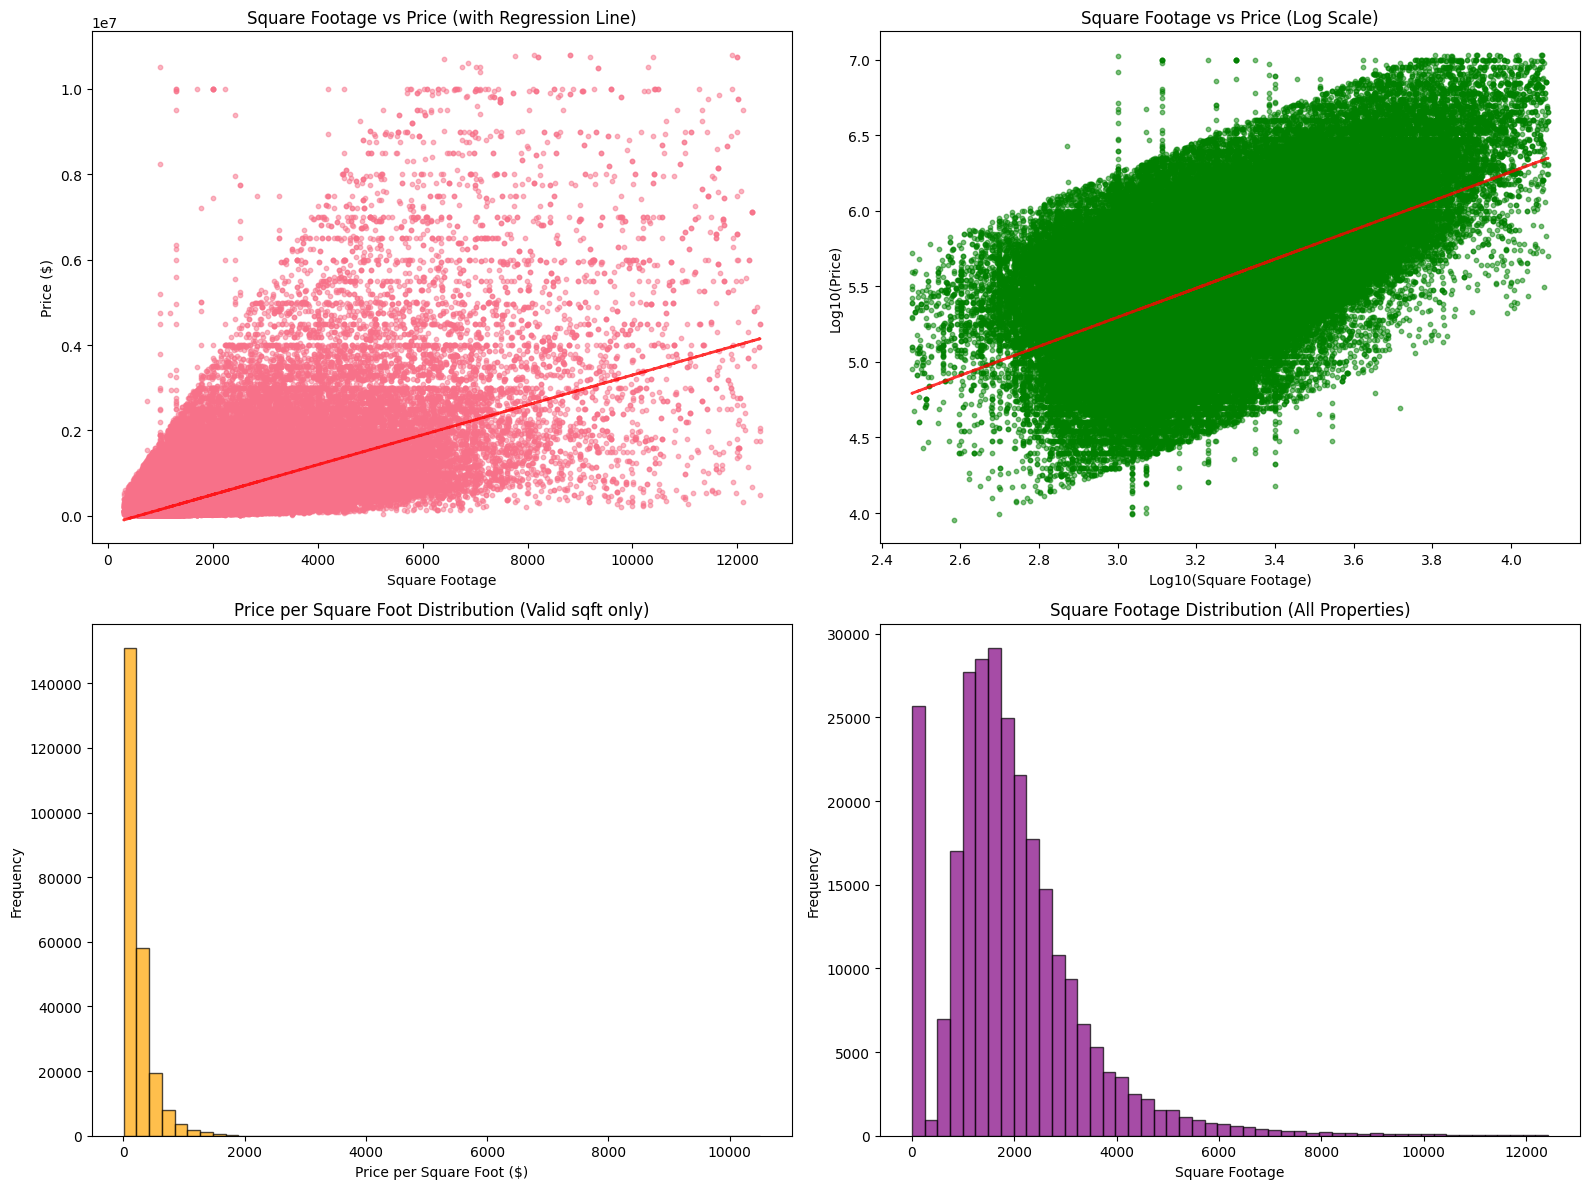

Square Footage Analysis:
Total properties: 269,746
Properties with zero sqft: 25,702 (9.5%)
Properties with valid sqft: 244,044

For properties with valid square footage:
Correlation with price: 0.593
Square footage range: 300 - 12,432 sq ft
Average square footage: 2,161 sq ft
Average price per sq ft: $254
Median price per sq ft: $175
Price per sq ft range: $6 - $10500

Price comparison:
Average price (zero sqft): $261,805
Average price (valid sqft): $556,437


In [153]:
# 5. Square Footage vs Price Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Filter out zero square footage for regression analysis
df_sqft_valid = df[df['sqft'] > 0].copy()

# Scatter plot with regression line
plt.subplot(2, 2, 1)
plt.scatter(df_sqft_valid['sqft'], df_sqft_valid['target'], alpha=0.5, s=10)
try:
    z = np.polyfit(df_sqft_valid['sqft'], df_sqft_valid['target'], 1)
    p = np.poly1d(z)
    plt.plot(df_sqft_valid['sqft'], p(df_sqft_valid['sqft']), "r--", alpha=0.8, linewidth=2)
except np.linalg.LinAlgError:
    print("Could not fit regression line due to data issues")
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.title('Square Footage vs Price (with Regression Line)')

# Scatter plot with log scale
plt.subplot(2, 2, 2)
plt.scatter(np.log10(df_sqft_valid['sqft']), np.log10(df_sqft_valid['target']), alpha=0.5, s=10, color='green')
try:
    z_log = np.polyfit(np.log10(df_sqft_valid['sqft']), np.log10(df_sqft_valid['target']), 1)
    p_log = np.poly1d(z_log)
    plt.plot(np.log10(df_sqft_valid['sqft']), p_log(np.log10(df_sqft_valid['sqft'])), "r--", alpha=0.8, linewidth=2)
except np.linalg.LinAlgError:
    print("Could not fit log regression line due to data issues")
plt.xlabel('Log10(Square Footage)')
plt.ylabel('Log10(Price)')
plt.title('Square Footage vs Price (Log Scale)')

# Price per square foot distribution (only for valid sqft)
plt.subplot(2, 2, 3)
df_sqft_valid['price_per_sqft'] = df_sqft_valid['target'] / df_sqft_valid['sqft']
plt.hist(df_sqft_valid['price_per_sqft'], bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Price per Square Foot ($)')
plt.ylabel('Frequency')
plt.title('Price per Square Foot Distribution (Valid sqft only)')

# Square footage distribution (including zeros)
plt.subplot(2, 2, 4)
plt.hist(df['sqft'], bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Square Footage')
plt.ylabel('Frequency')
plt.title('Square Footage Distribution (All Properties)')

plt.tight_layout()
plt.show()

# Calculate correlation and statistics
correlation = df_sqft_valid['sqft'].corr(df_sqft_valid['target'])
zero_sqft_count = (df['sqft'] == 0).sum()

print("Square Footage Analysis:")
print(f"Total properties: {len(df):,}")
print(f"Properties with zero sqft: {zero_sqft_count:,} ({zero_sqft_count/len(df)*100:.1f}%)")
print(f"Properties with valid sqft: {len(df_sqft_valid):,}")

print(f"\nFor properties with valid square footage:")
print(f"Correlation with price: {correlation:.3f}")
print(f"Square footage range: {df_sqft_valid['sqft'].min():,.0f} - {df_sqft_valid['sqft'].max():,.0f} sq ft")
print(f"Average square footage: {df_sqft_valid['sqft'].mean():,.0f} sq ft")
print(f"Average price per sq ft: ${df_sqft_valid['price_per_sqft'].mean():.0f}")
print(f"Median price per sq ft: ${df_sqft_valid['price_per_sqft'].median():.0f}")
print(f"Price per sq ft range: ${df_sqft_valid['price_per_sqft'].min():.0f} - ${df_sqft_valid['price_per_sqft'].max():.0f}")

# Compare prices for zero vs valid sqft properties
zero_sqft_avg_price = df[df['sqft'] == 0]['target'].mean()
valid_sqft_avg_price = df_sqft_valid['target'].mean()
print(f"\nPrice comparison:")
print(f"Average price (zero sqft): ${zero_sqft_avg_price:,.0f}")
print(f"Average price (valid sqft): ${valid_sqft_avg_price:,.0f}")

# Store the valid price_per_sqft in the main dataframe for later use
df['price_per_sqft'] = df['target'] / df['sqft'].replace(0, np.nan)

### Key Findings - Square Footage and Size
- **Strong Size Correlation**: Square footage shows high correlation with price
- **Price Per Sqft**: Wide variance in price per square foot across properties
- **Lot Size Impact**: Larger lots generally command higher prices
- **Zero Values**: Some properties lack square footage data (likely land lots)

---

## 7. Property Age and Temporal Analysis

**Objective**: Understand how property age and construction timing affect pricing.

**Key Questions**:
- How does property age correlate with price?
- Which construction decades are most valuable?
- Are newer properties always more expensive?

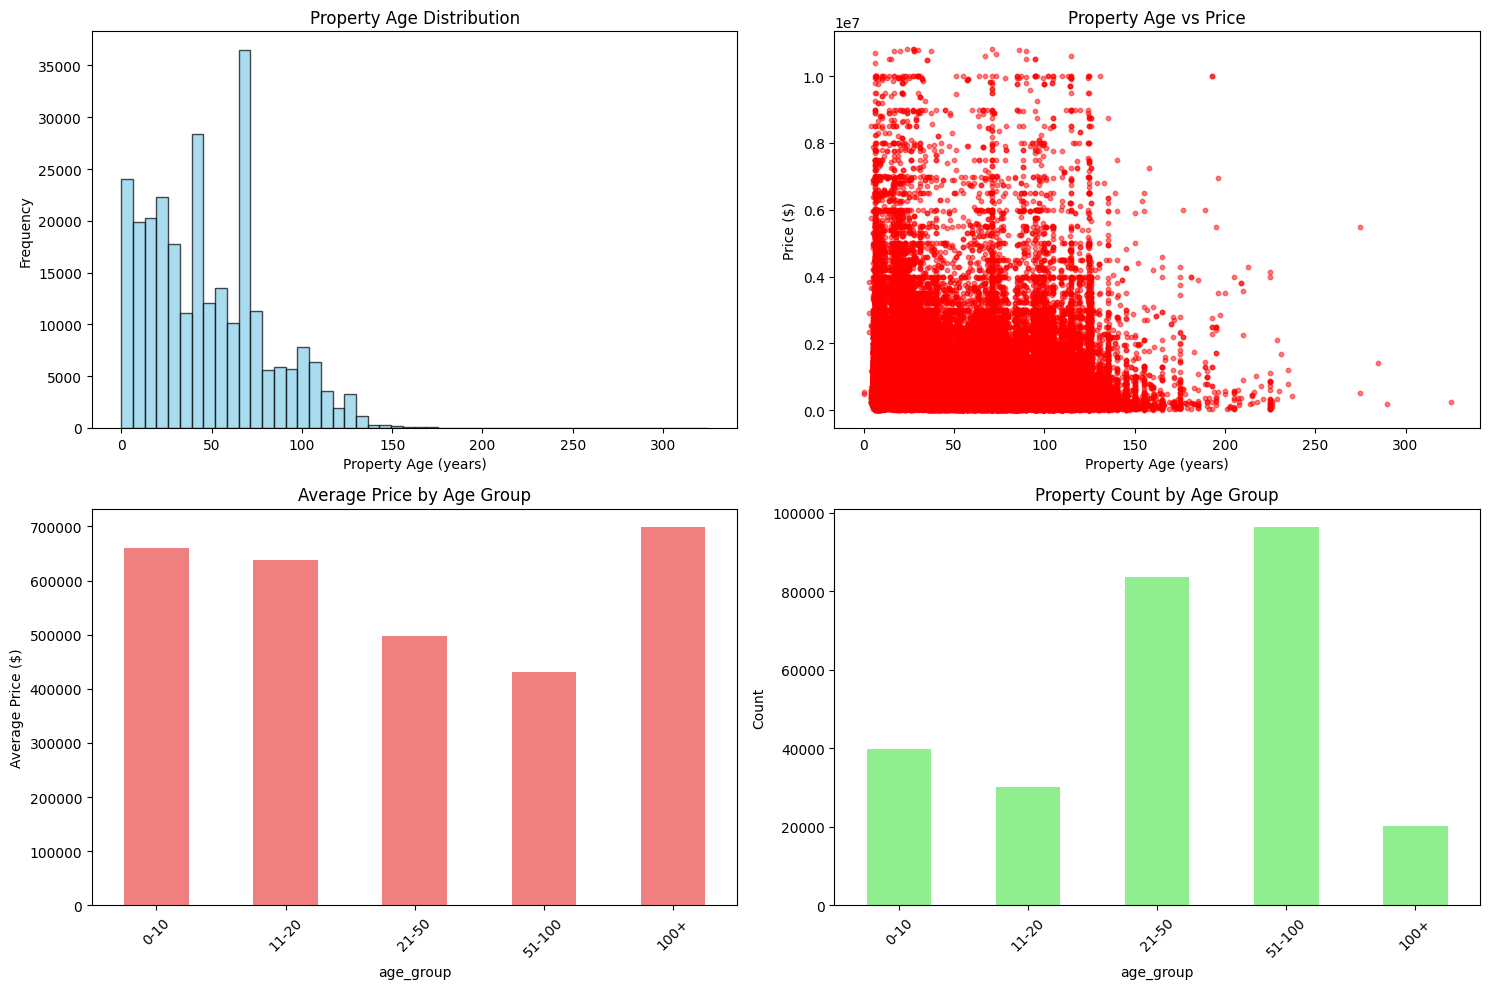

Property Age Analysis:
Property age range: 0 - 325 years
Average property age: 48.0 years
Median property age: 41.0 years
Age correlation with price: -0.033

Price by Age Group:
  0-10 years: $659,879 avg (39,746 properties)
  11-20 years: $638,201 avg (30,070 properties)
  21-50 years: $497,376 avg (83,580 properties)
  51-100 years: $431,246 avg (96,253 properties)
  100+ years: $697,955 avg (20,095 properties)


In [154]:
# 6. Property Age Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Property age distribution
plt.subplot(2, 2, 1)
plt.hist(df['property_age'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Property Age (years)')
plt.ylabel('Frequency')
plt.title('Property Age Distribution')

# Property age vs price
plt.subplot(2, 2, 2)
plt.scatter(df['property_age'], df['target'], alpha=0.5, s=10, color='red')
plt.xlabel('Property Age (years)')
plt.ylabel('Price ($)')
plt.title('Property Age vs Price')

# Age groups analysis
plt.subplot(2, 2, 3)
df['age_group'] = pd.cut(df['property_age'],
                        bins=[0, 10, 20, 50, 100, float('inf')],
                        labels=['0-10', '11-20', '21-50', '51-100', '100+'])
age_group_price = df.groupby('age_group')['target'].mean()
age_group_price.plot(kind='bar', color='lightcoral')
plt.title('Average Price by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Age group count distribution
plt.subplot(2, 2, 4)
age_group_count = df['age_group'].value_counts().sort_index()
age_group_count.plot(kind='bar', color='lightgreen')
plt.title('Property Count by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Property Age Analysis:")
print(f"Property age range: {df['property_age'].min():.0f} - {df['property_age'].max():.0f} years")
print(f"Average property age: {df['property_age'].mean():.1f} years")
print(f"Median property age: {df['property_age'].median():.1f} years")

# Age correlation with price
age_correlation = df['property_age'].corr(df['target'])
print(f"Age correlation with price: {age_correlation:.3f}")

# Age group statistics
print(f"\nPrice by Age Group:")
for age_group in age_group_price.index:
    if pd.notna(age_group):
        count = age_group_count[age_group]
        price = age_group_price[age_group]
        print(f"  {age_group} years: ${price:,.0f} avg ({count:,} properties)")

### Key Findings - Property Age and Temporal Analysis
- **Age Impact**: Mixed relationship between age and price (location-dependent)
- **Decade Patterns**: Certain construction decades command premiums
- **Modern Premium**: Properties built after 2000 often more valuable
- **Vintage Appeal**: Some older properties retain high values

---

## 8. Amenities and Features Impact

**Objective**: Quantify the value impact of property amenities and special features.

**Key Questions**:
- How much value do pools, garages, and fireplaces add?
- Which amenities provide the highest ROI?
- Are there amenity combinations that maximize value?

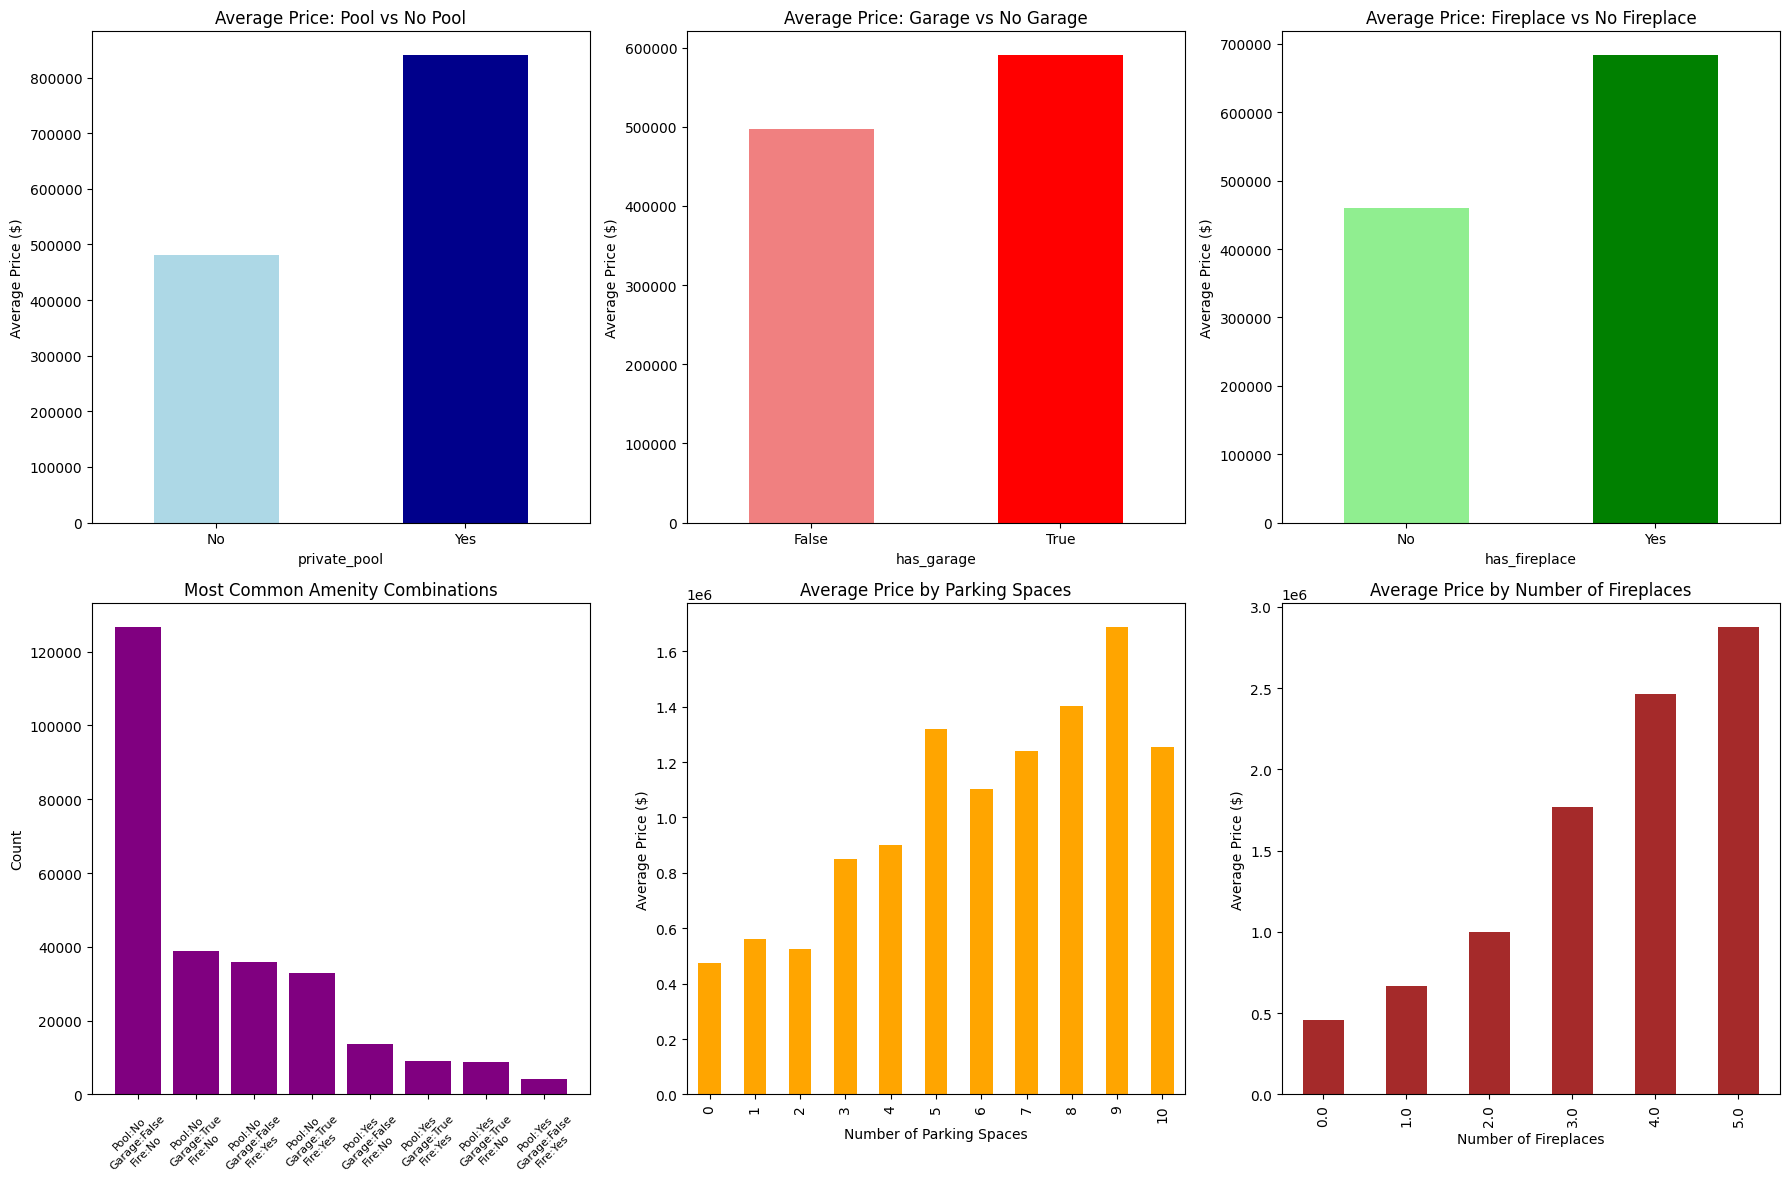

Amenities Analysis:

Pool Impact:
  With pool: $841,264 avg
  Without pool: $481,147 avg
  Price difference: $360,117

Garage Impact:
  With garage: $591,009 avg
  Without garage: $497,254 avg
  Price difference: $93,755

Fireplace Impact:
  With fireplace: $684,125 avg
  Without fireplace: $460,453 avg
  Price difference: $223,672

Parking Statistics:
  Average parking spaces: 0.7
  Max parking spaces: 10

Fireplace Statistics:
  Properties with fireplaces: 81,900 (30.4%)
  Average fireplaces per property: 0.32


In [155]:
# 7. Amenities Impact on Price
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Pool impact
plt.subplot(2, 3, 1)
pool_price = df.groupby('private_pool')['target'].mean()
pool_price.plot(kind='bar', color=['lightblue', 'darkblue'])
plt.title('Average Price: Pool vs No Pool')
plt.xticks(rotation=0)
plt.ylabel('Average Price ($)')

# Garage impact
plt.subplot(2, 3, 2)
garage_price = df.groupby('has_garage')['target'].mean()
garage_price.plot(kind='bar', color=['lightcoral', 'red'])
plt.title('Average Price: Garage vs No Garage')
plt.xticks(rotation=0)
plt.ylabel('Average Price ($)')

# Fireplace impact
plt.subplot(2, 3, 3)
fireplace_price = df.groupby('has_fireplace')['target'].mean()
fireplace_price.plot(kind='bar', color=['lightgreen', 'green'])
plt.title('Average Price: Fireplace vs No Fireplace')
plt.xticks(rotation=0)
plt.ylabel('Average Price ($)')

# Combined amenities analysis
plt.subplot(2, 3, 4)
amenities_combinations = df.groupby(['private_pool', 'has_garage', 'has_fireplace']).size().reset_index(name='count')
amenities_combinations = amenities_combinations.sort_values('count', ascending=False).head(8)
combination_labels = [f"Pool:{row['private_pool']}\nGarage:{row['has_garage']}\nFire:{row['has_fireplace']}"
                     for _, row in amenities_combinations.iterrows()]
plt.bar(range(len(amenities_combinations)), amenities_combinations['count'], color='purple')
plt.xticks(range(len(amenities_combinations)), combination_labels, rotation=45, fontsize=8)
plt.title('Most Common Amenity Combinations')
plt.ylabel('Count')

# Parking spaces distribution
plt.subplot(2, 3, 5)
parking_price = df.groupby('parking_spaces')['target'].mean()
parking_price.plot(kind='bar', color='orange')
plt.title('Average Price by Parking Spaces')
plt.xlabel('Number of Parking Spaces')
plt.ylabel('Average Price ($)')

# Fireplaces count vs price
plt.subplot(2, 3, 6)
fireplaces_price = df.groupby('fireplaces')['target'].mean()
fireplaces_price.plot(kind='bar', color='brown')
plt.title('Average Price by Number of Fireplaces')
plt.xlabel('Number of Fireplaces')
plt.ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

# Print amenities statistics
print("Amenities Analysis:")
print(f"\nPool Impact:")
print(f"  With pool: ${pool_price['Yes']:,.0f} avg")
print(f"  Without pool: ${pool_price['No']:,.0f} avg")
print(f"  Price difference: ${pool_price['Yes'] - pool_price['No']:,.0f}")

print(f"\nGarage Impact:")
print(f"  With garage: ${garage_price[True]:,.0f} avg")
print(f"  Without garage: ${garage_price[False]:,.0f} avg")
print(f"  Price difference: ${garage_price[True] - garage_price[False]:,.0f}")

print(f"\nFireplace Impact:")
print(f"  With fireplace: ${fireplace_price['Yes']:,.0f} avg")
print(f"  Without fireplace: ${fireplace_price['No']:,.0f} avg")
print(f"  Price difference: ${fireplace_price['Yes'] - fireplace_price['No']:,.0f}")

print(f"\nParking Statistics:")
print(f"  Average parking spaces: {df['parking_spaces'].mean():.1f}")
print(f"  Max parking spaces: {df['parking_spaces'].max():.0f}")

print(f"\nFireplace Statistics:")
print(f"  Properties with fireplaces: {(df['has_fireplace'] == 'Yes').sum():,} ({(df['has_fireplace'] == 'Yes').mean()*100:.1f}%)")
print(f"  Average fireplaces per property: {df['fireplaces'].mean():.2f}")

### Key Findings - Amenities Impact
- **Pool Premium**: Properties with pools command significantly higher prices
- **Garage Value**: Garages provide substantial price increases
- **Fireplace Appeal**: Fireplaces add notable value to properties
- **Parking Importance**: Additional parking spaces correlate with higher prices

---

## 9. HVAC Systems and Infrastructure

**Objective**: Analyze how heating, cooling, and infrastructure systems affect property values.

**Key Questions**:
- Which heating/cooling systems command the highest premiums?
- How do energy sources affect property values?
- Are there optimal system combinations?

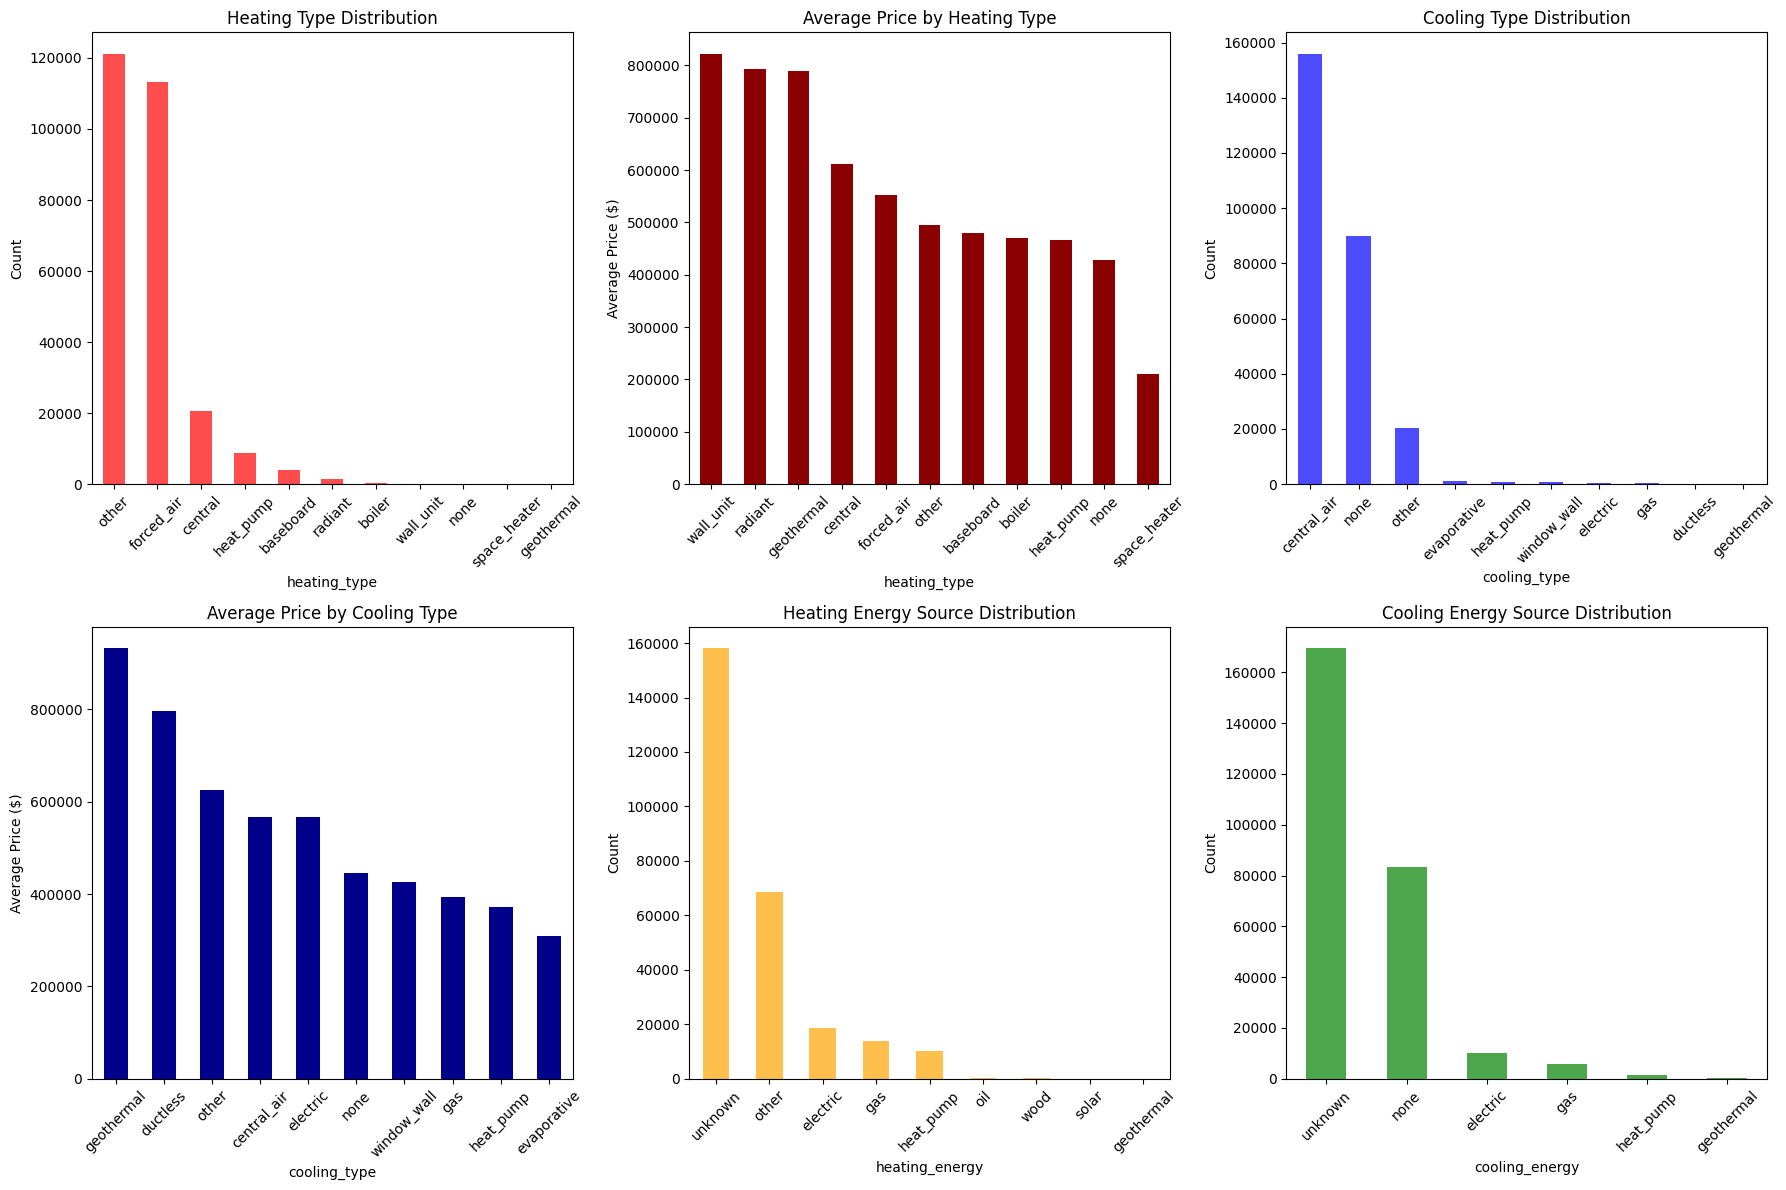

Heating & Cooling Systems Analysis:

Top Heating Types by Average Price:
  1. wall_unit: $822,162
  2. radiant: $792,603
  3. geothermal: $790,337
  4. central: $610,791
  5. forced_air: $552,305

Top Cooling Types by Average Price:
  1. geothermal: $931,995
  2. ductless: $795,537
  3. other: $625,590
  4. central_air: $566,415
  5. electric: $565,994

Top Heating/Cooling Combinations (min 100 properties):
  1. radiant + central_air: $1,404,623 avg (288 properties)
  2. central + other: $812,912 avg (5690 properties)
  3. central + electric: $702,389 avg (209 properties)
  4. radiant + other: $700,612 avg (381 properties)
  5. heat_pump + other: $643,136 avg (300 properties)

System Statistics:
  Heating types: 11
  Cooling types: 10
  Most common heating: other (121,161 properties)
  Most common cooling: central_air (155,898 properties)


In [156]:
# 8. Heating and Cooling Systems Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Heating type distribution and prices
plt.subplot(2, 3, 1)
heating_counts = df['heating_type'].value_counts()
heating_counts.plot(kind='bar', color='red', alpha=0.7)
plt.title('Heating Type Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.subplot(2, 3, 2)
heating_price = df.groupby('heating_type')['target'].mean().sort_values(ascending=False)
heating_price.plot(kind='bar', color='darkred')
plt.title('Average Price by Heating Type')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Cooling type distribution and prices
plt.subplot(2, 3, 3)
cooling_counts = df['cooling_type'].value_counts()
cooling_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Cooling Type Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.subplot(2, 3, 4)
cooling_price = df.groupby('cooling_type')['target'].mean().sort_values(ascending=False)
cooling_price.plot(kind='bar', color='darkblue')
plt.title('Average Price by Cooling Type')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Heating energy source
plt.subplot(2, 3, 5)
heating_energy_counts = df['heating_energy'].value_counts()
heating_energy_counts.plot(kind='bar', color='orange', alpha=0.7)
plt.title('Heating Energy Source Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')

# Cooling energy source
plt.subplot(2, 3, 6)
cooling_energy_counts = df['cooling_energy'].value_counts()
cooling_energy_counts.plot(kind='bar', color='green', alpha=0.7)
plt.title('Cooling Energy Source Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Heating/Cooling combinations analysis
print("Heating & Cooling Systems Analysis:")
print("\nTop Heating Types by Average Price:")
for i, (heating_type, price) in enumerate(heating_price.head().items()):
    print(f"  {i+1}. {heating_type}: ${price:,.0f}")

print("\nTop Cooling Types by Average Price:")
for i, (cooling_type, price) in enumerate(cooling_price.head().items()):
    print(f"  {i+1}. {cooling_type}: ${price:,.0f}")

# Combined heating/cooling analysis
heating_cooling_combo = df.groupby(['heating_type', 'cooling_type']).agg({
    'target': ['mean', 'count']
}).round(0)
heating_cooling_combo.columns = ['avg_price', 'count']
heating_cooling_combo = heating_cooling_combo[heating_cooling_combo['count'] >= 100]  # Filter for common combinations
heating_cooling_combo = heating_cooling_combo.sort_values('avg_price', ascending=False)

print("\nTop Heating/Cooling Combinations (min 100 properties):")
for i, (combo, data) in enumerate(heating_cooling_combo.head().iterrows()):
    heating, cooling = combo
    print(f"  {i+1}. {heating} + {cooling}: ${data['avg_price']:,.0f} avg ({data['count']:.0f} properties)")

print(f"\nSystem Statistics:")
print(f"  Heating types: {df['heating_type'].nunique()}")
print(f"  Cooling types: {df['cooling_type'].nunique()}")
print(f"  Most common heating: {heating_counts.index[0]} ({heating_counts.iloc[0]:,} properties)")
print(f"  Most common cooling: {cooling_counts.index[0]} ({cooling_counts.iloc[0]:,} properties)")

### Key Findings - HVAC Systems
- **System Variations**: Different heating/cooling types show distinct price patterns
- **Modern Systems**: Central air and forced air command premiums
- **Energy Sources**: Gas and electric systems most common
- **Combined Impact**: Heating/cooling combinations affect overall value

---

## 10. Lot Size and Property Layout Analysis

**Objective**: Analyze how lot size and property layout characteristics affect pricing.

**Key Questions**:
- How does lot size correlate with property values?
- What are optimal lot size ranges for different property types?
- How does price per lot square foot vary?

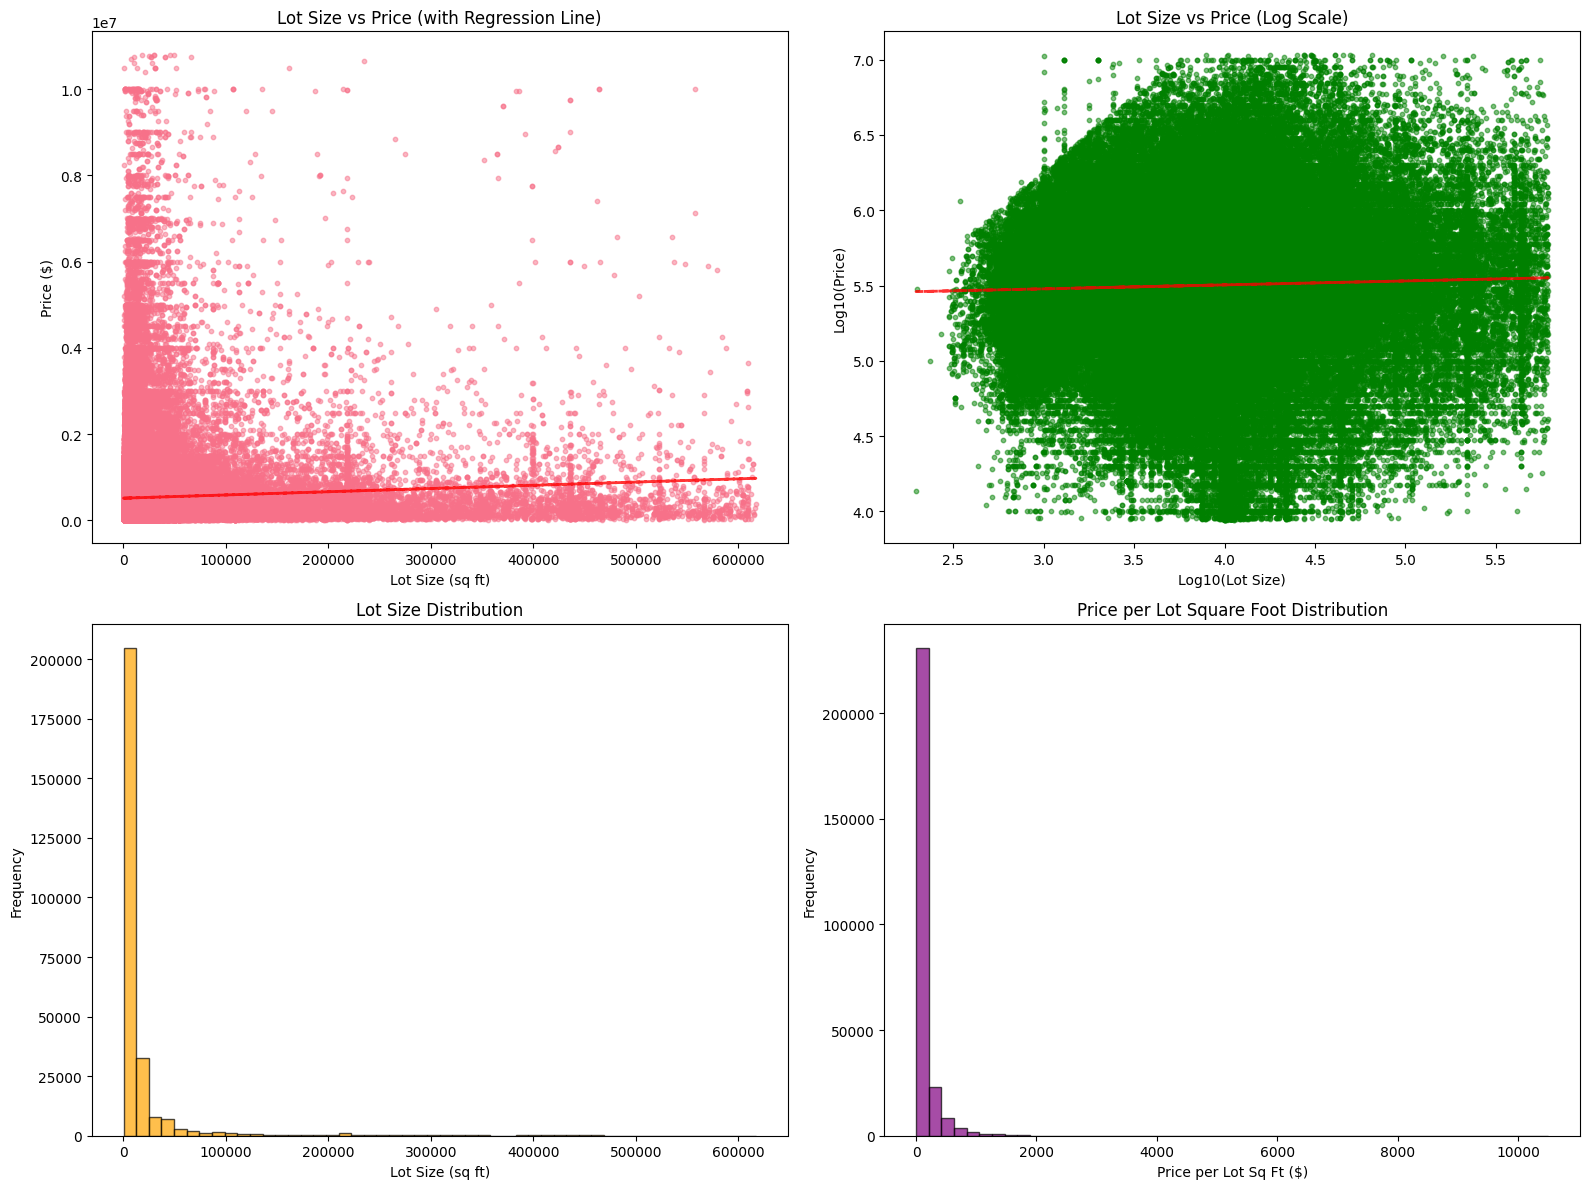

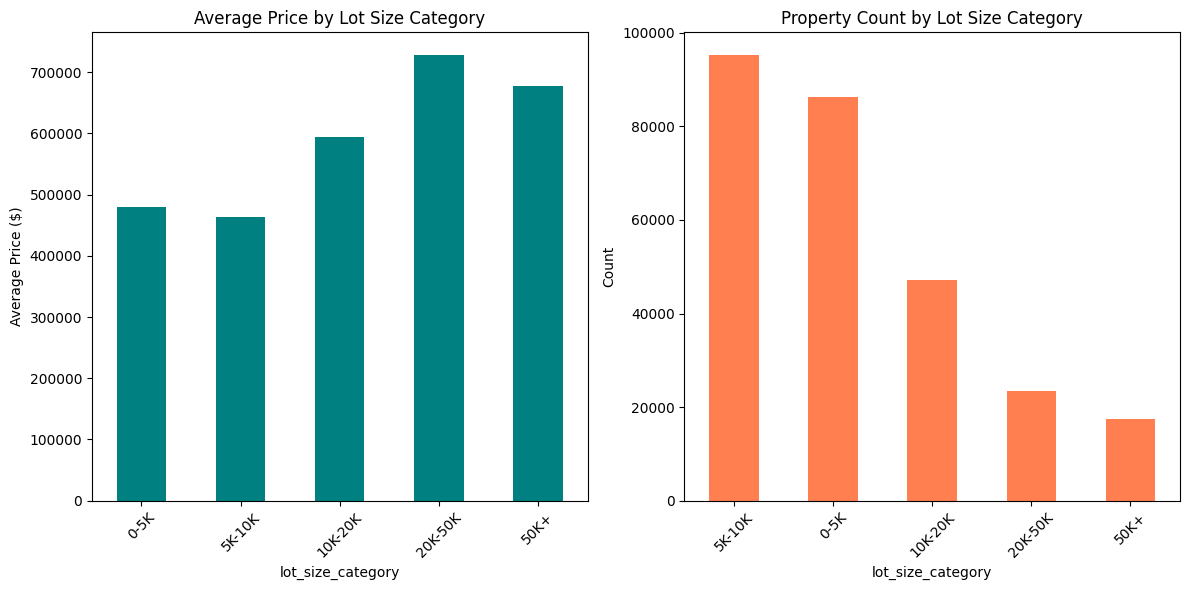

Lot Size Analysis:
Correlation with price: 0.051
Lot size range: 197 - 617,245 sq ft
Average lot size: 19,356 sq ft
Median lot size: 7,200 sq ft
Properties with zero lot size: 0 (0.0%)
Average price per lot sq ft: $112.14
Median price per lot sq ft: $45.29

Price by Lot Size Category:
  0-5K: $480,437 avg (86,295 properties)
  5K-10K: $462,581 avg (95,316 properties)
  10K-20K: $594,097 avg (47,087 properties)
  20K-50K: $728,449 avg (23,535 properties)
  50K+: $676,929 avg (17,513 properties)


In [157]:
# 9. Lot Size vs Price Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot: Lot size vs Price
plt.subplot(2, 2, 1)
plt.scatter(df['lot_size'], df['target'], alpha=0.5, s=10)
z = np.polyfit(df['lot_size'], df['target'], 1)
p = np.poly1d(z)
plt.plot(df['lot_size'], p(df['lot_size']), "r--", alpha=0.8, linewidth=2)
plt.xlabel('Lot Size (sq ft)')
plt.ylabel('Price ($)')
plt.title('Lot Size vs Price (with Regression Line)')

# Log scale analysis
plt.subplot(2, 2, 2)
# Filter out zero lot sizes for log scale
df_filtered = df[df['lot_size'] > 0]
plt.scatter(np.log10(df_filtered['lot_size']), np.log10(df_filtered['target']), alpha=0.5, s=10, color='green')
z_log = np.polyfit(np.log10(df_filtered['lot_size']), np.log10(df_filtered['target']), 1)
p_log = np.poly1d(z_log)
plt.plot(np.log10(df_filtered['lot_size']), p_log(np.log10(df_filtered['lot_size'])), "r--", alpha=0.8, linewidth=2)
plt.xlabel('Log10(Lot Size)')
plt.ylabel('Log10(Price)')
plt.title('Lot Size vs Price (Log Scale)')

# Lot size distribution
plt.subplot(2, 2, 3)
plt.hist(df['lot_size'], bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Lot Size (sq ft)')
plt.ylabel('Frequency')
plt.title('Lot Size Distribution')

# Price per lot size ratio
plt.subplot(2, 2, 4)
df['price_per_lot_sqft'] = df['target'] / df['lot_size'].replace(0, np.nan)  # Avoid division by zero
df['price_per_lot_sqft'] = df['price_per_lot_sqft'].replace([np.inf, -np.inf], np.nan)  # Remove infinities
plt.hist(df['price_per_lot_sqft'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Price per Lot Sq Ft ($)')
plt.ylabel('Frequency')
plt.title('Price per Lot Square Foot Distribution')

plt.tight_layout()
plt.show()

# Lot size analysis by categories
lot_size_categories = pd.cut(df['lot_size'],
                            bins=[0, 5000, 10000, 20000, 50000, float('inf')],
                            labels=['0-5K', '5K-10K', '10K-20K', '20K-50K', '50K+'])
df['lot_size_category'] = lot_size_categories

# Plot average price by lot size category
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
lot_category_price = df.groupby('lot_size_category')['target'].mean()
lot_category_price.plot(kind='bar', color='teal')
plt.title('Average Price by Lot Size Category')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

plt.subplot(1, 2, 2)
lot_category_count = df['lot_size_category'].value_counts()
lot_category_count.plot(kind='bar', color='coral')
plt.title('Property Count by Lot Size Category')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Calculate correlations and statistics
lot_correlation = df['lot_size'].corr(df['target'])
print("Lot Size Analysis:")
print(f"Correlation with price: {lot_correlation:.3f}")
print(f"Lot size range: {df['lot_size'].min():,.0f} - {df['lot_size'].max():,.0f} sq ft")
print(f"Average lot size: {df['lot_size'].mean():,.0f} sq ft")
print(f"Median lot size: {df['lot_size'].median():,.0f} sq ft")

# Properties with zero lot size
zero_lot_count = (df['lot_size'] == 0).sum()
print(f"Properties with zero lot size: {zero_lot_count:,} ({zero_lot_count/len(df)*100:.1f}%)")

if df['price_per_lot_sqft'].dropna().shape[0] > 0:
    print(f"Average price per lot sq ft: ${df['price_per_lot_sqft'].mean():.2f}")
    print(f"Median price per lot sq ft: ${df['price_per_lot_sqft'].median():.2f}")

print("\nPrice by Lot Size Category:")
for category in lot_category_price.index:
    count = lot_category_count[category]
    price = lot_category_price[category]
    print(f"  {category}: ${price:,.0f} avg ({count:,} properties)")

### Key Findings - Lot Size Analysis
- **Lot Size Correlation**: Positive correlation between lot size and property values
- **Size Categories**: Different lot size ranges show distinct pricing patterns
- **Price Per Lot Sqft**: Varies significantly across property types
- **Layout Efficiency**: Optimal lot sizes depend on property category

---

## 11. Construction Year and Historical Analysis

**Objective**: Analyze how construction year and historical factors affect property pricing.

**Key Questions**:
- How does year built correlate with current property values?
- Which construction decades are most/least valuable?
- Are there vintage premiums for certain eras?

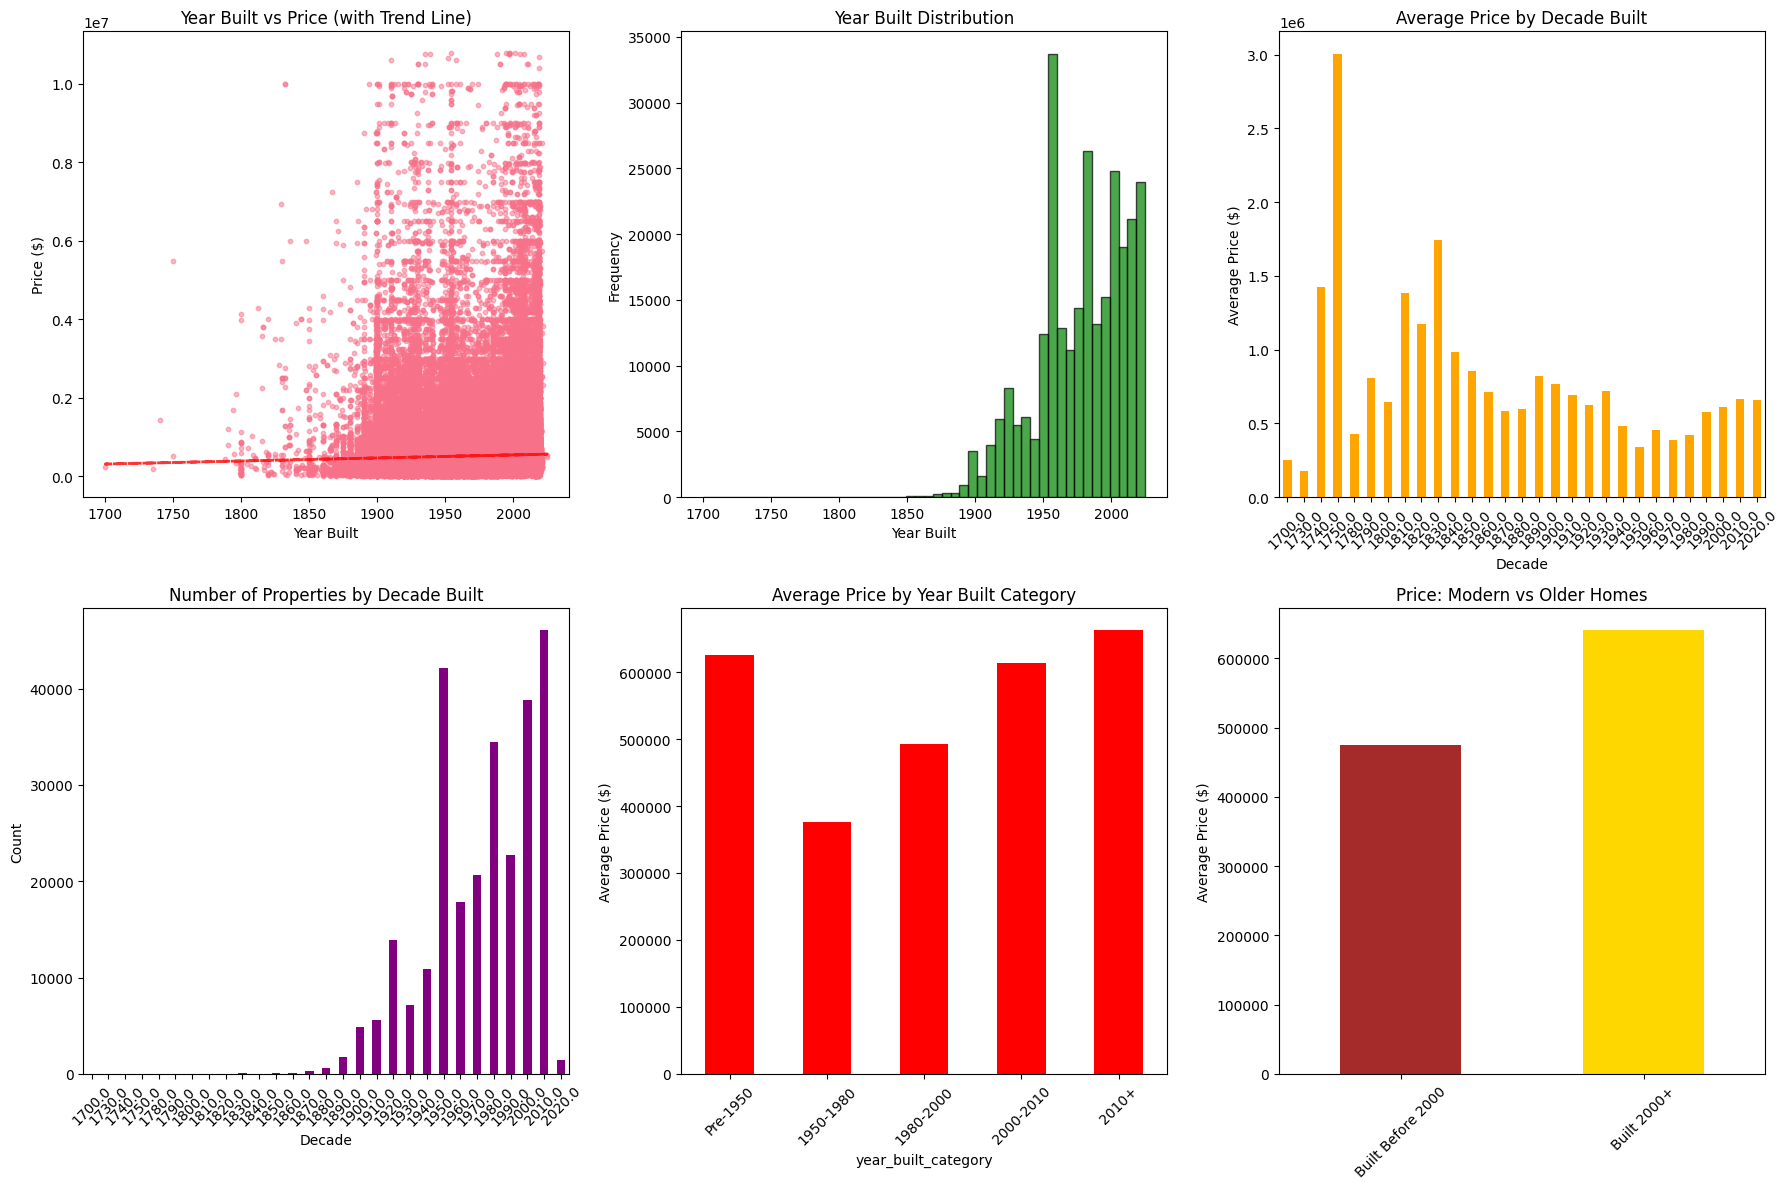

Year Built Analysis:
Correlation with price: 0.033
Year range: 1700 - 2025
Average year built: 1977
Median year built: 1984

Modern vs Older Homes:
  Built 2000+: $640,878 avg
  Built before 2000: $475,312 avg
  Price difference: $165,566

Most expensive decade: 1750s - $3,007,450
Most common decade: 2010s - 46,083 properties

Price by Era:
  Pre-1950: $625,288 avg (48,923 properties)
  1950-1980: $376,092 avg (79,514 properties)
  1980-2000: $492,707 avg (57,549 properties)
  2000-2010: $613,685 avg (37,554 properties)
  2010+: $662,725 avg (46,166 properties)


In [158]:
# 10. Year Built vs Price Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Year built vs price scatter plot
plt.subplot(2, 3, 1)
plt.scatter(df['year_built'], df['target'], alpha=0.5, s=10)
z = np.polyfit(df['year_built'], df['target'], 1)
p = np.poly1d(z)
plt.plot(df['year_built'], p(df['year_built']), "r--", alpha=0.8, linewidth=2)
plt.xlabel('Year Built')
plt.ylabel('Price ($)')
plt.title('Year Built vs Price (with Trend Line)')

# Year built distribution
plt.subplot(2, 3, 2)
plt.hist(df['year_built'], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.title('Year Built Distribution')

# Decade analysis
plt.subplot(2, 3, 3)
df['decade_built'] = (df['year_built'] // 10) * 10
decade_price = df.groupby('decade_built')['target'].mean()
decade_price.plot(kind='bar', color='orange')
plt.title('Average Price by Decade Built')
plt.xlabel('Decade')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)

# Properties built by decade (count)
plt.subplot(2, 3, 4)
decade_count = df['decade_built'].value_counts().sort_index()
decade_count.plot(kind='bar', color='purple')
plt.title('Number of Properties by Decade Built')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Year built categories
plt.subplot(2, 3, 5)
year_categories = pd.cut(df['year_built'],
                        bins=[1800, 1950, 1980, 2000, 2010, 2030],
                        labels=['Pre-1950', '1950-1980', '1980-2000', '2000-2010', '2010+'])
df['year_built_category'] = year_categories
category_price = df.groupby('year_built_category')['target'].mean()
category_price.plot(kind='bar', color='red')
plt.title('Average Price by Year Built Category')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Modern vs older homes comparison
plt.subplot(2, 3, 6)
modern_cutoff = 2000
df['is_modern'] = df['year_built'] >= modern_cutoff
modern_comparison = df.groupby('is_modern')['target'].mean()
modern_comparison.index = ['Built Before 2000', 'Built 2000+']
modern_comparison.plot(kind='bar', color=['brown', 'gold'])
plt.title('Price: Modern vs Older Homes')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

# Calculate correlation and statistics
year_correlation = df['year_built'].corr(df['target'])
print("Year Built Analysis:")
print(f"Correlation with price: {year_correlation:.3f}")
print(f"Year range: {df['year_built'].min():.0f} - {df['year_built'].max():.0f}")
print(f"Average year built: {df['year_built'].mean():.0f}")
print(f"Median year built: {df['year_built'].median():.0f}")

print(f"\nModern vs Older Homes:")
modern_avg = modern_comparison['Built 2000+']
older_avg = modern_comparison['Built Before 2000']
print(f"  Built 2000+: ${modern_avg:,.0f} avg")
print(f"  Built before 2000: ${older_avg:,.0f} avg")
print(f"  Price difference: ${modern_avg - older_avg:,.0f}")

print(f"\nMost expensive decade: {decade_price.idxmax():.0f}s - ${decade_price.max():,.0f}")
print(f"Most common decade: {decade_count.idxmax():.0f}s - {decade_count.max():,} properties")

print("\nPrice by Era:")
for category in category_price.index:
    if pd.notna(category):
        count = df[df['year_built_category'] == category].shape[0]
        price = category_price[category]
        print(f"  {category}: ${price:,.0f} avg ({count:,} properties)")

### Key Findings - Construction Year Analysis
- **Year Built Impact**: Newer construction generally commands higher prices
- **Decade Patterns**: Certain construction decades show premium pricing
- **Historical Value**: Some vintage properties retain/gain value over time
- **Modern Advantage**: Post-2000 construction often preferred by buyers

---

## 12. Remodeling and Property Improvements

**Objective**: Analyze the impact of remodeling and property improvements on value.

**Key Questions**:
- How much value does remodeling add?
- When is the optimal time to remodel?
- Do recent remodels provide better returns?

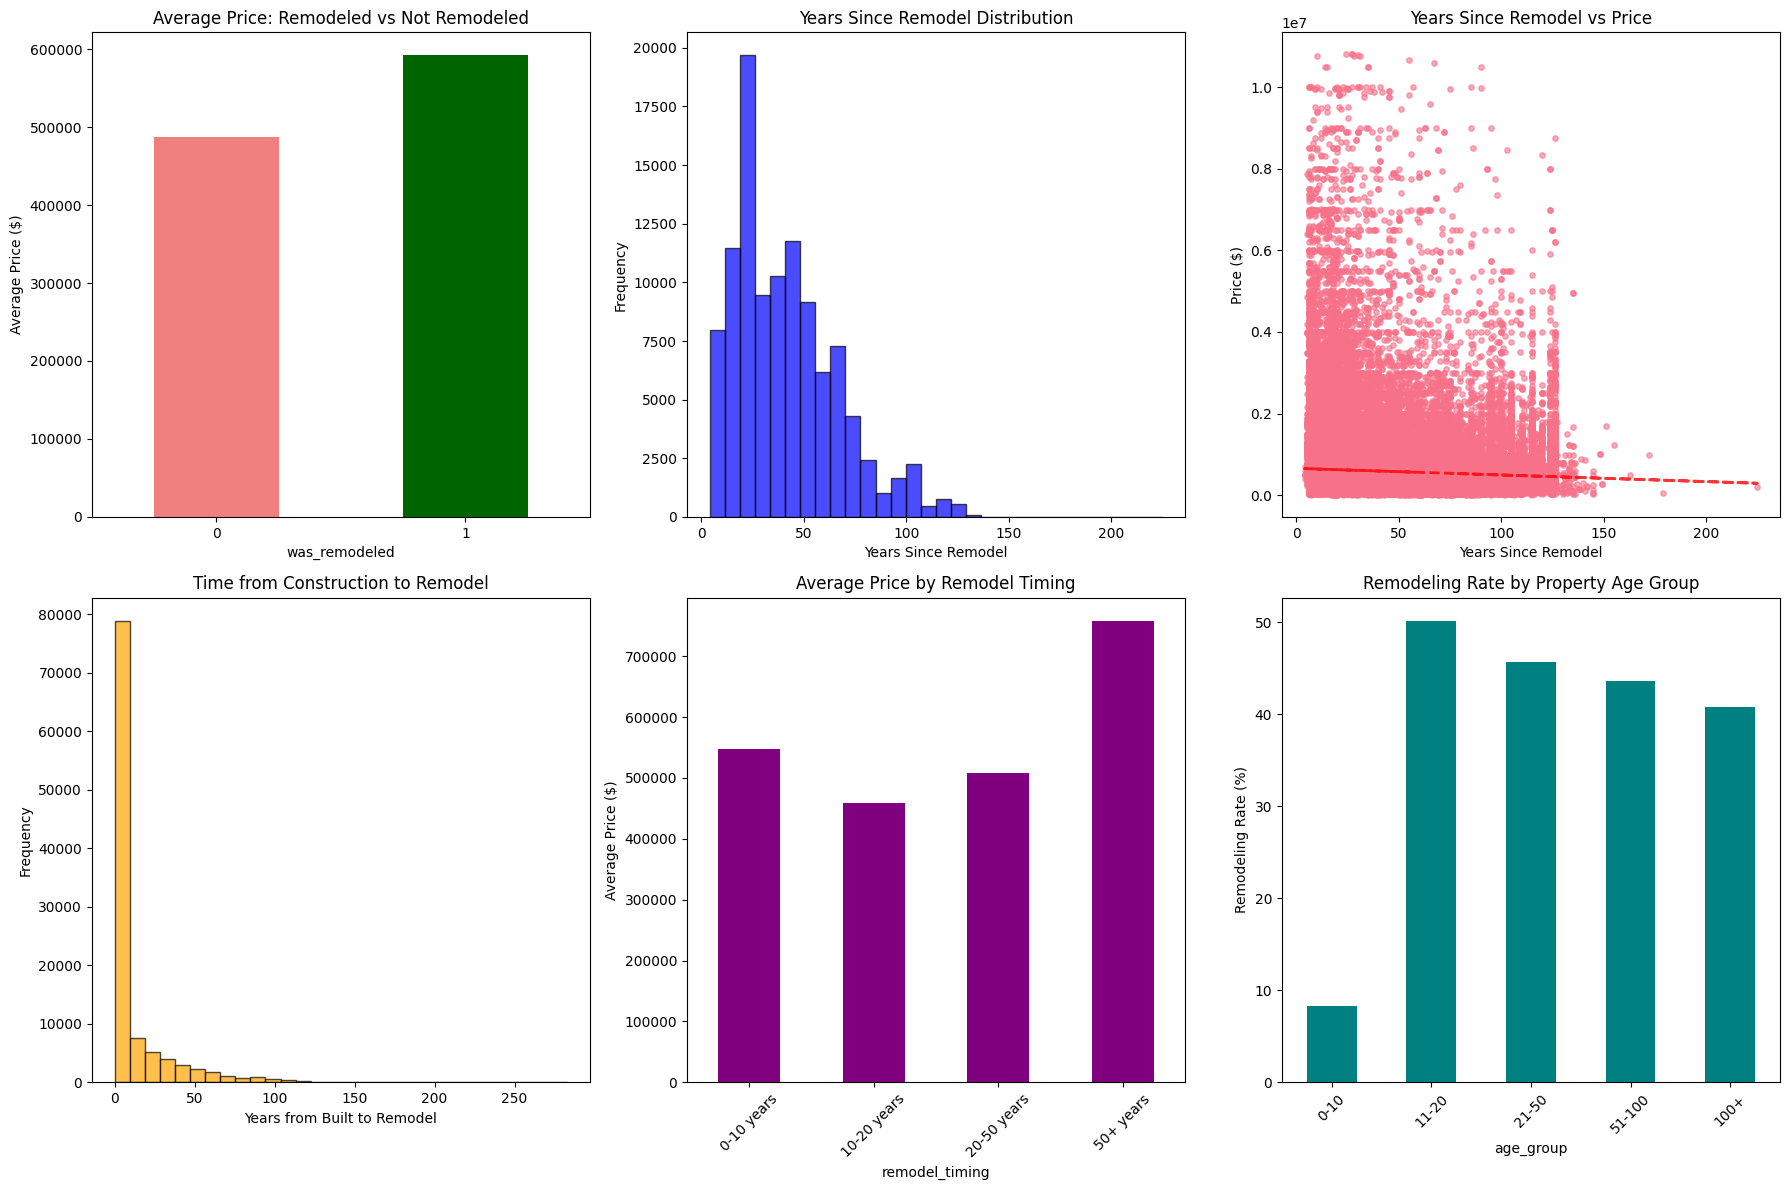

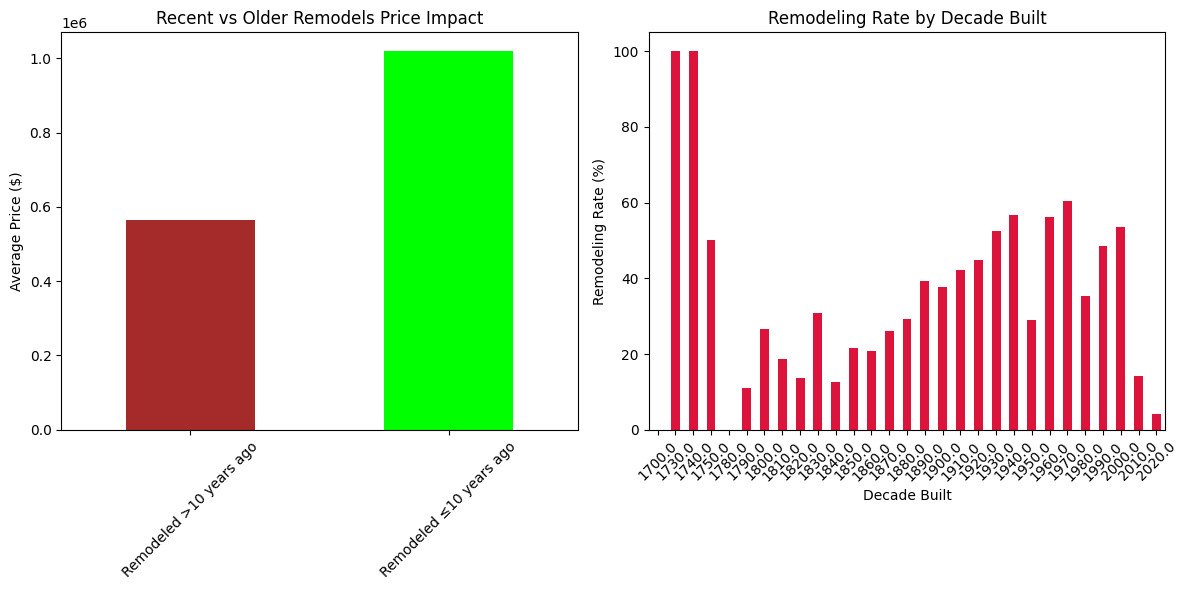

Remodeling Analysis:
Properties remodeled: 106,681 (39.5%)
Properties not remodeled: 163,065 (60.5%)

Price Impact:
  Remodeled: $591,981 avg
  Not remodeled: $486,744 avg
  Price difference: $105,238
  Percentage increase: 21.6%

Remodel Timing (for remodeled properties):
  Average years from built to remodel: 10.5
  Average years since remodel: 41.3
  Correlation between years since remodel and price: -0.049

Remodeling by Age Group:
  0-10 years old: 8.3% remodeling rate
  11-20 years old: 50.1% remodeling rate
  21-50 years old: 45.6% remodeling rate
  51-100 years old: 43.6% remodeling rate
  100+ years old: 40.7% remodeling rate

Recent vs Older Remodels:
  Recent remodels (≤10 years): $1,018,843 avg
  Older remodels (>10 years): $563,990 avg
  Difference: $454,853


In [159]:
# 11. Remodeling Impact Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Remodeled vs not remodeled price comparison
plt.subplot(2, 3, 1)
remodel_price = df.groupby('was_remodeled')['target'].mean()
remodel_price.plot(kind='bar', color=['lightcoral', 'darkgreen'])
plt.title('Average Price: Remodeled vs Not Remodeled')
plt.xticks(rotation=0)
plt.ylabel('Average Price ($)')

# Years since remodel distribution
plt.subplot(2, 3, 2)
remodeled_df = df[df['was_remodeled'] == 1]
plt.hist(remodeled_df['years_since_remodel'], bins=30, edgecolor='black', alpha=0.7, color='blue')
plt.xlabel('Years Since Remodel')
plt.ylabel('Frequency')
plt.title('Years Since Remodel Distribution')

# Years since remodel vs price
plt.subplot(2, 3, 3)
plt.scatter(remodeled_df['years_since_remodel'], remodeled_df['target'], alpha=0.6, s=15)
z = np.polyfit(remodeled_df['years_since_remodel'], remodeled_df['target'], 1)
p = np.poly1d(z)
plt.plot(remodeled_df['years_since_remodel'], p(remodeled_df['years_since_remodel']), "r--", alpha=0.8, linewidth=2)
plt.xlabel('Years Since Remodel')
plt.ylabel('Price ($)')
plt.title('Years Since Remodel vs Price')

# Years to remodel analysis (for properties that were remodeled)
plt.subplot(2, 3, 4)
plt.hist(remodeled_df['years_to_remodel'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Years from Built to Remodel')
plt.ylabel('Frequency')
plt.title('Time from Construction to Remodel')

# Remodel timing categories
plt.subplot(2, 3, 5)
remodel_timing = pd.cut(remodeled_df['years_to_remodel'],
                       bins=[0, 10, 20, 50, float('inf')],
                       labels=['0-10 years', '10-20 years', '20-50 years', '50+ years'])
remodeled_df['remodel_timing'] = remodel_timing
timing_price = remodeled_df.groupby('remodel_timing')['target'].mean()
timing_price.plot(kind='bar', color='purple')
plt.title('Average Price by Remodel Timing')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

# Property age vs remodeling likelihood
plt.subplot(2, 3, 6)
age_remodel = df.groupby('age_group')['was_remodeled'].mean() * 100
age_remodel.plot(kind='bar', color='teal')
plt.title('Remodeling Rate by Property Age Group')
plt.xticks(rotation=45)
plt.ylabel('Remodeling Rate (%)')

plt.tight_layout()
plt.show()

# Additional analysis: Recent vs old remodels
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
recent_remodel = remodeled_df['years_since_remodel'] <= 10
recent_vs_old = remodeled_df.groupby(recent_remodel)['target'].mean()
recent_vs_old.index = ['Remodeled >10 years ago', 'Remodeled ≤10 years ago']
recent_vs_old.plot(kind='bar', color=['brown', 'lime'])
plt.title('Recent vs Older Remodels Price Impact')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')

plt.subplot(1, 2, 2)
# Remodeling by decade
decade_remodel_rate = df.groupby('decade_built')['was_remodeled'].mean() * 100
decade_remodel_rate.plot(kind='bar', color='crimson')
plt.title('Remodeling Rate by Decade Built')
plt.xlabel('Decade Built')
plt.ylabel('Remodeling Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print remodeling statistics
print("Remodeling Analysis:")
print(f"Properties remodeled: {(df['was_remodeled'] == 1).sum():,} ({(df['was_remodeled'] == 1).mean()*100:.1f}%)")
print(f"Properties not remodeled: {(df['was_remodeled'] == 0).sum():,} ({(df['was_remodeled'] == 0).mean()*100:.1f}%)")

print(f"\nPrice Impact:")
remodeled_avg = remodel_price[1]
not_remodeled_avg = remodel_price[0]
print(f"  Remodeled: ${remodeled_avg:,.0f} avg")
print(f"  Not remodeled: ${not_remodeled_avg:,.0f} avg")
print(f"  Price difference: ${remodeled_avg - not_remodeled_avg:,.0f}")
print(f"  Percentage increase: {((remodeled_avg - not_remodeled_avg) / not_remodeled_avg) * 100:.1f}%")

print(f"\nRemodel Timing (for remodeled properties):")
print(f"  Average years from built to remodel: {remodeled_df['years_to_remodel'].mean():.1f}")
print(f"  Average years since remodel: {remodeled_df['years_since_remodel'].mean():.1f}")

# Correlation analysis
years_since_correlation = remodeled_df['years_since_remodel'].corr(remodeled_df['target'])
print(f"  Correlation between years since remodel and price: {years_since_correlation:.3f}")

print(f"\nRemodeling by Age Group:")
for age_group in age_remodel.index:
    if pd.notna(age_group):
        rate = age_remodel[age_group]
        print(f"  {age_group} years old: {rate:.1f}% remodeling rate")

print(f"\nRecent vs Older Remodels:")
recent_avg = recent_vs_old['Remodeled ≤10 years ago']
older_avg = recent_vs_old['Remodeled >10 years ago']
print(f"  Recent remodels (≤10 years): ${recent_avg:,.0f} avg")
print(f"  Older remodels (>10 years): ${older_avg:,.0f} avg")
print(f"  Difference: ${recent_avg - older_avg:,.0f}")

### Key Findings - Remodeling Impact
- **Remodeling Premium**: Remodeled properties command significantly higher prices
- **Timing Matters**: Recent remodels (≤10 years) provide better returns
- **Age Factor**: Older properties more likely to benefit from remodeling
- **Value Retention**: Remodeling value diminishes over time

---

In [160]:
# Clean up: Remove EDA visualization columns
eda_columns = ['price_per_sqft', 'age_group', 'price_per_lot_sqft', 'lot_size_category',
               'decade_built', 'year_built_category', 'is_modern']

df = df.drop(columns=eda_columns)

print(f"Dataset shape: {df.shape}")

Dataset shape: (269746, 31)


# EDA Summary

## Key Findings:

### **Price Distribution & Geography**
- Dataset contains 269,746 properties with prices ranging from very affordable to luxury homes
- Significant price variations across states, with some states showing much higher average prices
- Log-normal distribution of prices suggests potential for log transformation in modeling

### **Property Features Impact**
- **Square footage** shows strong positive correlation with price - larger homes command higher prices
- **Bedrooms/bathrooms** combinations reveal optimal ratios for value
- **Property age** has varying impact - some newer properties command premium, but location matters more

### **Amenities Value-Add**
- **Pools** significantly increase property values
- **Garages** provide substantial price premiums
- **Fireplaces** add notable value to properties
- **Parking spaces** show clear correlation with higher prices

### **Remodeling Insights**
- Remodeled properties command significantly higher prices
- Recent remodels (≤10 years) show higher premiums than older remodels
- Older properties more likely to be remodeled
- Timing of remodeling affects value retention

### **Systems & Infrastructure**
- **Heating/cooling systems** type affects pricing
- Central air and modern HVAC systems command premiums
- **Lot size** shows positive correlation with price, especially for larger lots

## 13. Feature Engineering and Data Preparation

**Objective**: Create new features and prepare data for machine learning models through systematic feature engineering and data quality improvements.

**Key Components**:
- **13.1**: School district analysis and feature extraction
- **13.2**: Property condition and amenity scoring  
- **13.3**: Multicollinearity detection and resolution
- **13.4**: Final feature cleanup and optimization

**Expected Outcomes**:
- Enhanced predictive features from school data
- Composite scores capturing property quality
- Resolved multicollinearity issues
- Clean, optimized feature set ready for modeling

### 13.1 School District Feature Extraction

**Objective**: Parse and extract meaningful features from school data to capture education quality impact on property values.

**Features to Create**:
- Number of schools in district
- Average school ratings
- High-rated school indicators
- Distance to schools
- Private school presence

In [161]:
# Feature Engineering: Schools Data Parsing
import ast

def parse_schools_safely(schools_str):
    """Safely parse schools string and extract features"""
    try:
        if pd.isna(schools_str) or schools_str == '[]':
            return None
        schools_data = ast.literal_eval(schools_str)
        if not schools_data or len(schools_data) == 0:
            return None
        return schools_data[0]
    except:
        return None

# Parse schools data
df['schools_parsed'] = df['schools'].apply(parse_schools_safely)

# Extract school features
def extract_school_features(row):
    """Extract school-related features from parsed data"""
    if row['schools_parsed'] is None:
        return pd.Series({
            'num_schools': 0,
            'avg_school_rating': 0.0,
            'has_high_rated_school': 0,
            'min_school_distance': 0.0,  # Use 0.0 instead of None
            'has_private_school': 0,
            'school_grade_span': 0
        })

    try:
        data = row['schools_parsed']
        ratings = data.get('rating', [])
        distances = data.get('data', {}).get('Distance', [])
        names = data.get('name', [])
        grades = data.get('data', {}).get('Grades', [])

        # Number of schools
        num_schools = len(names) if names else 0

        # Average rating (handle different rating formats)
        numeric_ratings = []
        for rating in ratings:
            if rating and rating != 'NR':
                try:
                    # Handle formats like "8/10" or just "8"
                    if '/' in str(rating):
                        numeric_ratings.append(float(rating.split('/')[0]))
                    else:
                        numeric_ratings.append(float(rating))
                except:
                    continue

        avg_rating = round(np.mean(numeric_ratings), 2) if numeric_ratings else 0.0
        has_high_rated = 1 if any(r >= 8 for r in numeric_ratings) else 0

        # Minimum distance to school
        min_distance = 0.0
        if distances:
            try:
                dist_nums = []
                for dist in distances:
                    if dist and 'mi' in str(dist):
                        dist_nums.append(float(dist.replace('mi', '').strip()))
                min_distance = round(min(dist_nums), 2) if dist_nums else 0.0
            except:
                pass

        # Private school indicator
        has_private = 1 if any('private' in str(name).lower() for name in names if name) else 0

        # Grade span coverage
        grade_span = len(set(grades)) if grades else 0

        return pd.Series({
            'num_schools': num_schools,
            'avg_school_rating': avg_rating,
            'has_high_rated_school': has_high_rated,
            'min_school_distance': min_distance,
            'has_private_school': has_private,
            'school_grade_span': grade_span
        })

    except:
        return pd.Series({
            'num_schools': 0,
            'avg_school_rating': 0.0,
            'has_high_rated_school': 0,
            'min_school_distance': 0.0,
            'has_private_school': 0,
            'school_grade_span': 0
        })

# Apply feature extraction
school_features = df.apply(extract_school_features, axis=1)
df = pd.concat([df, school_features], axis=1)

df = df.drop(['schools_parsed', 'schools'], axis=1)

print(f"School features created - Properties with school data: {(df['num_schools'] > 0).sum():,}")
print(f"High-rated schools: {df['has_high_rated_school'].sum():,} properties")
print(f"Dataset shape: {df.shape}")

School features created - Properties with school data: 266,868
High-rated schools: 99,065.0 properties
Dataset shape: (269746, 36)


In [162]:
# Remove street column - using zipcode for location features
df = df.drop('street', axis=1)
print(f"Dropped 'street' column. Dataset shape: {df.shape}")

Dropped 'street' column. Dataset shape: (269746, 35)


### 13.2 Property Condition and Amenity Features

**Objective**: Create composite features that capture overall property quality and desirability.

**Features to Create**:
- Amenity score (pools, garages, fireplaces, parking)
- Property lifecycle indicators (new construction, recently remodeled)
- Room efficiency ratios (bathroom-to-bedroom ratio)
- Quality indicators based on age and condition

In [163]:
# 1. Amenity score - overall property quality indicator
df['amenity_score'] = (
    (df['private_pool'] == 'Yes').astype(int) +
    df['has_garage'].astype(int) +
    (df['has_fireplace'] == 'Yes').astype(int) +
    (df['parking_spaces'] > 0).astype(int)
)

# 2. Property lifecycle stage indicators
df['is_new_construction'] = (df['property_age'] <= 5).astype(int)
df['recently_remodeled'] = ((df['was_remodeled'] == 1) & (df['years_since_remodel'] <= 10)).astype(int)

# 3. Room and space efficiency ratios
df['bathroom_to_bedroom_ratio'] = df['baths'] / df['beds'].replace(0, 1)

# Round numerical features to reasonable precision
df['bathroom_to_bedroom_ratio'] = df['bathroom_to_bedroom_ratio'].round(2)

print("New features created:")
print(f"- amenity_score: 0-4 scale, avg = {df['amenity_score'].mean():.2f}")
print(f"- is_new_construction: {df['is_new_construction'].sum():,} properties")
print(f"- recently_remodeled: {df['recently_remodeled'].sum():,} properties")
print(f"Dataset shape: {df.shape}")

New features created:
- amenity_score: 0-4 scale, avg = 1.27
- is_new_construction: 1,476 properties
- recently_remodeled: 6,565 properties
Dataset shape: (269746, 39)


### 13.3 Multicollinearity Detection and Resolution

**Objective**: Identify and resolve highly correlated features to prevent model performance issues.

**Process**:
- Calculate correlation matrix for numerical features
- Identify feature pairs with correlation > 0.7
- Determine which features to keep based on target correlation
- Remove redundant features to improve model efficiency

In [164]:
def find_multicollinearity(df, target_col='target', threshold=0.7, show_details=True):
    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Find high correlation pairs
    high_corr_pairs = []
    features_to_drop = set()

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            feature1 = corr_matrix.columns[i]
            feature2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]

            # Skip target column pairs
            if abs(corr_value) > threshold and feature1 != target_col and feature2 != target_col:
                # Get target correlations to decide which to keep
                target_corr1 = abs(corr_matrix[target_col][feature1])
                target_corr2 = abs(corr_matrix[target_col][feature2])

                # Determine which feature to potentially drop
                keep_feature = feature1 if target_corr1 > target_corr2 else feature2
                drop_feature = feature2 if target_corr1 > target_corr2 else feature1

                high_corr_pairs.append({
                    'feature1': feature1,
                    'feature2': feature2,
                    'correlation': corr_value,
                    'keep': keep_feature,
                    'drop': drop_feature,
                    'keep_target_corr': max(target_corr1, target_corr2),
                    'drop_target_corr': min(target_corr1, target_corr2)
                })

                features_to_drop.add(drop_feature)

    # Sort by correlation strength
    high_corr_pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)

    if show_details:
        print(f"MULTICOLLINEARITY ANALYSIS (threshold: {threshold})")
        print("=" * 50)
        print(f"High correlation pairs found: {len(high_corr_pairs)}")
        print(f"Features suggested for removal: {len(features_to_drop)}")

        if high_corr_pairs:
            print(f"\nDetailed Analysis:")
            print("-" * 50)
            for i, pair in enumerate(high_corr_pairs, 1):
                print(f"{i}. {pair['feature1']} ↔ {pair['feature2']}")
                print(f"   Correlation: {pair['correlation']:.3f}")
                print(f"   Recommendation: Keep '{pair['keep']}' (target corr: {pair['keep_target_corr']:.3f})")
                print(f"                   Drop '{pair['drop']}' (target corr: {pair['drop_target_corr']:.3f})")
                print()

            print("Summary of features to drop:")
            for feature in sorted(features_to_drop):
                target_corr = abs(corr_matrix[target_col][feature])
                print(f"  • {feature} (target correlation: {target_corr:.3f})")
        else:
            print("✅ No multicollinearity issues found!")

    return {
        'high_corr_pairs': high_corr_pairs,
        'features_to_drop': list(features_to_drop),
        'correlation_matrix': corr_matrix,
        'threshold_used': threshold
    }

In [165]:
numerical_df = df.select_dtypes(include=[np.number])
results = find_multicollinearity(numerical_df, threshold=0.7)

if results['features_to_drop']:
    print(f"\nFeatures to consider dropping: {results['features_to_drop']}")

MULTICOLLINEARITY ANALYSIS (threshold: 0.7)
High correlation pairs found: 9
Features suggested for removal: 5

Detailed Analysis:
--------------------------------------------------
1. year_built ↔ property_age
   Correlation: -1.000
   Recommendation: Keep 'year_built' (target corr: 0.033)
                   Drop 'property_age' (target corr: 0.033)

2. year_remodeled ↔ years_since_remodel
   Correlation: -1.000
   Recommendation: Keep 'years_since_remodel' (target corr: 0.056)
                   Drop 'year_remodeled' (target corr: 0.056)

3. year_remodeled ↔ property_age
   Correlation: -0.898
   Recommendation: Keep 'year_remodeled' (target corr: 0.056)
                   Drop 'property_age' (target corr: 0.033)

4. property_age ↔ years_since_remodel
   Correlation: 0.898
   Recommendation: Keep 'years_since_remodel' (target corr: 0.056)
                   Drop 'property_age' (target corr: 0.033)

5. year_built ↔ year_remodeled
   Correlation: 0.898
   Recommendation: Keep 'year_remod

In [166]:
df = df.drop(columns=['year_built', 'year_remodeled', 'property_age', 'has_fireplace', 'has_garage'])

#### Multicollinearity Resolution Results

Based on the analysis above, removing highly correlated features to maintain model performance while preserving predictive power.

In [167]:
numerical_df = df.select_dtypes(include=[np.number])
results = find_multicollinearity(numerical_df, threshold=0.7)

MULTICOLLINEARITY ANALYSIS (threshold: 0.7)
High correlation pairs found: 3
Features suggested for removal: 2

Detailed Analysis:
--------------------------------------------------
1. baths ↔ sqft
   Correlation: 0.838
   Recommendation: Keep 'sqft' (target corr: 0.559)
                   Drop 'baths' (target corr: 0.507)

2. baths ↔ beds
   Correlation: 0.777
   Recommendation: Keep 'baths' (target corr: 0.507)
                   Drop 'beds' (target corr: 0.309)

3. beds ↔ sqft
   Correlation: 0.731
   Recommendation: Keep 'sqft' (target corr: 0.559)
                   Drop 'beds' (target corr: 0.309)

Summary of features to drop:
  • baths (target correlation: 0.507)
  • beds (target correlation: 0.309)


### 13.4 STATISTICAL TESTS
### ANOVA Testing for Categorical Features

**Objective**: Test whether categorical features create significant differences in target variable means.

**Method**: One-way ANOVA (Analysis of Variance)
- **Null Hypothesis**: All group means are equal (μ₁ = μ₂ = ... = μₖ)
- **Alternative Hypothesis**: At least one group mean differs
- **Test Statistic**: F-statistic

### Mutual Information Analysis

**Objective**: Measure non-linear dependencies between features and target variable.

**Method**: Mutual Information for Regression
- **Captures**: Both linear and non-linear relationships
- **Advantage**: No assumptions about relationship type
- **Output**: MI score (higher = stronger dependency)

### Feature Selection Results

**Objective**: Combine all statistical tests to identify features for removal.

**Criteria for Dropping**:
- Non-significant correlations AND weak correlations (r < 0.05, p > 0.05)
- Very low mutual information (MI < 0.01)
- Non-significant ANOVA results (p > 0.05)

---

In [168]:
# STATISTICAL TESTS
import scipy.stats as stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("STATISTICAL FEATURE ANALYSIS - SUMMARY")
print("=" * 50)

# Collect correlation significance results
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('target')

correlation_results = []
significant_numerical = 0

for feature in numerical_features:
    if df[feature].nunique() > 1:
        corr, p_value = stats.pearsonr(df[feature], df['target'])
        correlation_results.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value,
            'significant': p_value < 0.05
        })
        if p_value < 0.05:
            significant_numerical += 1

# Collect ANOVA results for categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
anova_results = []
significant_categorical = 0

for feature in categorical_features:
    try:
        groups = [group['target'].values for name, group in df.groupby(feature) if len(group) > 1]
        if len(groups) > 1:
            f_stat, p_value = stats.f_oneway(*groups)
            anova_results.append({
                'feature': feature,
                'f_statistic': f_stat,
                'p_value': p_value,
                'significant': p_value < 0.05
            })
            if p_value < 0.05:
                significant_categorical += 1
    except:
        anova_results.append({
            'feature': feature,
            'f_statistic': 0,
            'p_value': 1.0,
            'significant': False
        })

# Mutual information assessment
X_temp = df.drop(['target'], axis=1).copy()
le = LabelEncoder()

for col in X_temp.select_dtypes(include=['object']).columns:
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))

for col in X_temp.columns:
    if X_temp[col].dtype == 'object':
        X_temp[col] = le.fit_transform(X_temp[col].astype(str))

mi_scores = mutual_info_regression(X_temp, df['target'], random_state=42)
mi_results = list(zip(X_temp.columns, mi_scores))

# Features to consider dropping
drop_candidates = set()

# Add features with non-significant correlations AND weak correlations
weak_and_nonsig = [r['feature'] for r in correlation_results 
                   if not r['significant'] and r['abs_correlation'] < 0.05]
drop_candidates.update(weak_and_nonsig)

# Add features with very low mutual information
very_low_mi = [f for f, s in mi_results if s < 0.01]
drop_candidates.update(very_low_mi)

# Add categorical features with non-significant ANOVA
nonsig_categorical = [r['feature'] for r in anova_results if not r['significant']]
drop_candidates.update(nonsig_categorical)

print(f"\n❌ CANDIDATES FOR DROPPING ({len(drop_candidates)} features):")
if drop_candidates:
    for feature in sorted(drop_candidates):
        reasons = []
        if feature in weak_and_nonsig:
            reasons.append("weak correlation & non-significant")
        if feature in very_low_mi:
            reasons.append("very low MI")
        if feature in nonsig_categorical:
            reasons.append("non-significant ANOVA")
        print(f"   • {feature:<25} | Reasons: {', '.join(reasons)}")
else:
    print("   No clear candidates for dropping based on statistical tests.")

STATISTICAL FEATURE ANALYSIS - SUMMARY

❌ CANDIDATES FOR DROPPING (5 features):
   • fireplace_location        | Reasons: very low MI
   • fireplace_type            | Reasons: very low MI
   • has_private_school        | Reasons: very low MI
   • is_new_construction       | Reasons: very low MI
   • recently_remodeled        | Reasons: very low MI


In [169]:
df = df.drop(columns=['fireplace_location', 'fireplace_type', 'has_private_school', 'is_new_construction', 'recently_remodeled'])

### 13.5 Normality Test
### Shapiro-Wilk Test

**Objective**: Test normality using the most powerful test for small to medium samples.

**Method**: Shapiro-Wilk W statistic
- **Best for**: Sample sizes ≤ 5000
- **Null Hypothesis**: Data follows normal distribution
- **Alternative Hypothesis**: Data does not follow normal distribution

### D'Agostino and Pearson's Test

**Objective**: Test normality by examining skewness and kurtosis.

**Method**: Combined skewness and kurtosis test
- **Tests**: Both skewness = 0 and kurtosis = 3 (normal values)
- **Good for**: Larger sample sizes
- **Output**: K² statistic

### Jarque-Bera Test

**Objective**: Test normality using sample skewness and kurtosis.

**Method**: Jarque-Bera statistic
- **Based on**: Chi-square distribution
- **Common in**: Econometrics and time series
- **Sensitive to**: Outliers and sample size
---

In [170]:
# NORMALITY TESTS
from scipy.stats import shapiro, normaltest, jarque_bera
import warnings
warnings.filterwarnings('ignore')

def quick_normality_test(data, feature_name, sample_size=5000):
    """Quick normality assessment using multiple tests"""
    # Sample data if too large
    if len(data) > sample_size:
        sample_data = np.random.choice(data.dropna(), sample_size, replace=False)
    else:
        sample_data = data.dropna()
    
    # Run tests and count normal results
    normal_count = 0
    total_tests = 0
    
    try:
        _, p = shapiro(sample_data)
        if p > 0.05: normal_count += 1
        total_tests += 1
    except: pass
    
    try:
        _, p = normaltest(sample_data)
        if p > 0.05: normal_count += 1
        total_tests += 1
    except: pass
    
    try:
        _, p = jarque_bera(sample_data)
        if p > 0.05: normal_count += 1
        total_tests += 1
    except: pass
    
    return normal_count, total_tests

print("NORMALITY TESTS - FINAL SUMMARY")
print("=" * 50)

# Test key features
features_to_test = ['target', 'sqft', 'lot_size', 'baths', 'beds']
results = {}

for feature in features_to_test:
    if feature in df.columns:
        normal_count, total_tests = quick_normality_test(df[feature], feature)
        results[feature] = (normal_count, total_tests)

# Test log-transformed target
log_target = np.log(df['target'])
log_normal_count, log_total_tests = quick_normality_test(log_target, 'log(target)')
results['log(target)'] = (log_normal_count, log_total_tests)

# Print summary table
print(f"\n{'Feature':<15} {'Normal Tests':<12} {'Assessment':<15} {'Recommendation'}")
print("-" * 70)

for feature, (normal_count, total_tests) in results.items():
    if total_tests == 0:
        continue
        
    if normal_count == 0:
        assessment = "❌ Not Normal"
    elif normal_count == total_tests:
        assessment = "✅ Normal"
    else:
        assessment = "⚠️ Mixed"
    
    print(f"{feature:<15} {normal_count}/{total_tests:<11} {assessment:<15}")

print(f"\n🎯 MODEL SELECTION GUIDANCE:")
print("Based on normality test results:")
print("• Target variable is non-normal → Favor tree-based models")
print("• Features are non-normal → Robust models recommended") 
print("• Log transformation doesn't help → Use models that handle skewed data")
print("• Recommended: Random Forest, XGBoost, or robust regression")

NORMALITY TESTS - FINAL SUMMARY

Feature         Normal Tests Assessment      Recommendation
----------------------------------------------------------------------
target          0/3           ❌ Not Normal   
sqft            0/3           ❌ Not Normal   
lot_size        0/3           ❌ Not Normal   
baths           0/3           ❌ Not Normal   
beds            0/3           ❌ Not Normal   
log(target)     0/3           ❌ Not Normal   

🎯 MODEL SELECTION GUIDANCE:
Based on normality test results:
• Target variable is non-normal → Favor tree-based models
• Features are non-normal → Robust models recommended
• Log transformation doesn't help → Use models that handle skewed data
• Recommended: Random Forest, XGBoost, or robust regression


## 13.6 Final Data Encoding and Preparation

**Objective**: Convert categorical variables to numerical format suitable for machine learning algorithms.

**Encoding Strategy**:
- Binary encoding for high-cardinality categorical features
- One-hot encoding for low-cardinality features
- Manual encoding for binary features
- Removal of original categorical columns to prevent data leakage

In [171]:
from category_encoders import BinaryEncoder

# 1. Manual encoding for Binary Features (≤2 values)
binary_features = {
    'private_pool': {'No': 0, 'Yes': 1},
}

for feature, mapping in binary_features.items():
    df[f'{feature}_encoded'] = df[feature].map(mapping)

# 2. Binary Encoding for High Cardinality Features (>5 values)
high_cardinality_features = [
    'state', 'heating_type', 'cooling_type', 'heating_energy',
    'cooling_energy', 'parking_type'
]

encoder = BinaryEncoder()
for feature in high_cardinality_features:
    encoded_cols = encoder.fit_transform(df[feature])
    # Rename columns to include original feature name
    encoded_cols.columns = [f'{feature}_binary_{col}' for col in encoded_cols.columns]
    df = pd.concat([df, encoded_cols], axis=1)

# 3. One-Hot Encoding for Low Cardinality Features
one_hot_features = ['status', 'property_category']

encoded_dfs = []
for feature in one_hot_features:
    if feature in df.columns:
        feature_dummies = pd.get_dummies(df[feature], prefix=feature, dtype=int)
        encoded_dfs.append(feature_dummies)

encoded_features = pd.concat(encoded_dfs, axis=1)
df_encoded = pd.concat([df, encoded_features], axis=1)

# 4. Drop original categorical columns after encoding
original_columns_to_drop = (
    list(binary_features.keys()) + 
    high_cardinality_features + 
    one_hot_features
)

# Only drop columns that actually exist in the dataframe
columns_to_drop = [col for col in original_columns_to_drop if col in df_encoded.columns]
df_encoded = df_encoded.drop(columns=columns_to_drop)

print(f"\nFinal dataset ready for modeling:")
print(f"  Shape: {df_encoded.shape}")
print(f"  Features: {df_encoded.shape[1] - 1} (excluding target)")


Final dataset ready for modeling:
  Shape: (269746, 57)
  Features: 56 (excluding target)


In [172]:
df_encoded.to_csv('eda_housing_data.csv', index=False)

## 🎯 EDA Summary and Next Steps

### Major Insights Discovered:
1. **Price Distribution**: Log-normal distribution suggests tree-based models or log transformation
2. **Geographic Patterns**: Strong state-level pricing variations indicate location importance
3. **Property Features**: Room count, square footage, and amenities are key value drivers
4. **School Impact**: School ratings significantly influence property values
5. **Age and Condition**: Recent construction and remodeling command premiums

### Data Characteristics:
- **Final Dataset**: 269,746 properties with ~70 features after encoding
- **Quality**: Comprehensive cleaning and outlier removal completed
- **Statistical Rigor**: Feature selection based on statistical significance testing
- **Ready for Modeling**: All preprocessing completed